# Explore dataset structure

In [5]:
from dirs import *
from xflow import TransformRegistry as T
from xflow.utils.io import scan_files
from xflow.utils.sql import merge_sqlite_dbs
from xflow import SqlProvider, PyTorchPipeline, FileProvider
from xflow.data import build_transforms_from_config
from xflow.utils.visualization import plot_image
from xflow.extensions.physics import pattern_gen
from tqdm import tqdm
from copy import deepcopy

import numpy as np
from tqdm import tqdm
from xflow.extensions.physics.pipeline import (
    CachedBasisPipeline,
    IndexCombinator,
    SpatialNearestCombinator,
    make_centroid_position_extractor,
 )


from config_utils import load_config, detect_machine
import pandas as pd
import sqlite3
from utils import *

experiment_name = "CLEAR_visualization"  
config = load_config(
    f"{experiment_name}.yaml",
    machine=machine
)

[config_utils] Using machine profile: mac-andrewxu


# Load dataset

Different with training pipeline, data sample meta data is given

Mainly the run time sythetic dataset need to be compiled and generate here

In [ ]:
"""
Contract:
1. Unify the data format for visualization like (2, N, 1, 256, 256)
   (fiber_input_output_image_type, num_samples, C, H, W)
2. Add labels/colors or class to data samples with index based order matter.
3. Union data samples, labels and colors into three single iterable for downstream visualization.
"""

# ============================================================
# Small helpers
# ============================================================
def make_transforms(parent_dir, base_transform_cfg, drop_last=True):
    """
    Build transforms safely without mutating config["data"]["transforms"]["torch"].
    This fixes the repeated insert bug.
    """
    transform_cfg = [
        {
            "name": "add_parent_dir",
            "params": {"parent_dir": parent_dir},
        },
        *deepcopy(base_transform_cfg),
    ]
    transforms = build_transforms_from_config(transform_cfg)
    return transforms if drop_last else transforms


def to_modal_array(x):
    """
    Normalize data to shape (2, N, C, H, W).

    Common cases:
    - list/tuple with length 2, each item (N, C, H, W)
    - ndarray already in shape (2, N, C, H, W)
    - ndarray in shape (N, 2, C, H, W)
    """
    if isinstance(x, np.ndarray):
        arr = x
    else:
        arr = np.stack(x, axis=0)

    if arr.ndim != 5:
        raise ValueError(f"Expected ndim=5, got shape={arr.shape}")

    if arr.shape[0] == 2:
        return arr

    if arr.shape[1] == 2:
        return np.transpose(arr, (1, 0, 2, 3, 4))

    raise ValueError(f"Cannot convert to (2, N, C, H, W), got shape={arr.shape}")


def build_sql_provider(db_path, sql, subsample_n=None, seed=None):
    provider = SqlProvider(
        sources={"connection": db_path, "sql": sql},
        output_config={"list": "image_path"},
    )
    if subsample_n is not None:
        provider = provider.subsample(n_samples=subsample_n, seed=seed)
    return provider


def load_sql_pipeline(db_path, sql, parent_dir, *, subsample_n=None):
    """
    Standard SQL -> PyTorchPipeline -> numpy -> (2, N, C, H, W)
    """
    provider = build_sql_provider(
        db_path=db_path,
        sql=sql,
        subsample_n=subsample_n,
        seed=config["seed"],
    )
    transforms = make_transforms(
        parent_dir=parent_dir,
        base_transform_cfg=config["data"]["transforms"]["torch"],
        drop_last=True,
    )
    pipeline = PyTorchPipeline(provider, transforms).to_numpy()
    return to_modal_array(pipeline)

def load_files_pipeline(root_dir, subsample_n=None, extensions=None):
    provider = FileProvider(
    root_paths=root_dir,
    extensions=extensions, # None = all files
    path_type="string", # return paths as strings
    )
    if subsample_n is not None:
        provider = provider.subsample(n_samples=subsample_n, seed=config["seed"])
    transforms = make_transforms(
        parent_dir=root_dir,
        base_transform_cfg=config["data"]["transforms"]["torch"],
        drop_last=True,
    )

    pipeline = PyTorchPipeline(provider, transforms).to_numpy()
    return to_modal_array(pipeline)
    

def make_bundle(samples, label, color, name=None):
    """
    samples: (2, N, C, H, W)
    """
    n = samples.shape[1]
    return {
        "name": name,
        "samples": samples,
        "labels": [label] * n,
        "colors": [color] * n,
    }


def concat_bundles(*bundles, name="merged"):
    """
    Concatenate multiple bundles along sample axis.
    """
    samples = np.concatenate([b["samples"] for b in bundles], axis=1)
    labels = sum([b["labels"] for b in bundles], [])
    colors = sum([b["colors"] for b in bundles], [])
    return {
        "name": name,
        "samples": samples,
        "labels": labels,
        "colors": colors,
    }


def build_sgm_stream():
    """
    Reused by DMD synthetic builders.
    """
    canvas = pattern_gen.DynamicPatterns(*config["simulation"]["canvas_size"])
    canvas.set_postprocess_fns(
        build_transforms_from_config(config["simulation"]["process_functions"])
    )
    canvas._distributions = [
        pattern_gen.StaticGaussianDistribution(canvas)
        for _ in range(config["simulation"]["total_Guassian_num"])
    ]
    canvas.set_threshold(config["simulation"]["minimum_pixel_threshold"])

    stream = canvas.pattern_stream(
        std_1=config["simulation"]["std_1"],
        std_2=config["simulation"]["std_2"],
        max_intensity=config["simulation"]["max_intensity"],
        fade_rate=config["simulation"]["fade_rate"],
        distribution=config["simulation"]["distribution"],
    )
    return stream


def build_dmd_syth_plus_eval(
    db_path,
    extracted_dir,
    orth_sql,
    eval_sql,
    syth_label,
    eval_label,
    syth_color,
    eval_color,
    syth_take_n=1000,
):
    """
    DMD orthogonal basis + synthetic augmentation + eval set
    """
    # ---------- eval ----------
    eval_provider = build_sql_provider(db_path, eval_sql)
    eval_transforms = make_transforms(
        parent_dir=extracted_dir,
        base_transform_cfg=config["data"]["transforms"]["torch"],
        drop_last=True,
    )
    eval_pipeline = PyTorchPipeline(eval_provider, eval_transforms).to_numpy()
    eval_samples = to_modal_array(eval_pipeline)

    # ---------- synthetic ----------
    orth_provider = build_sql_provider(db_path, orth_sql)

    full_transforms = make_transforms(
        parent_dir=extracted_dir,
        base_transform_cfg=config["data"]["transforms"]["torch"],
        drop_last=False,
    )

    combinator = IndexCombinator(
        pattern_provider=build_sgm_stream(),
        transforms=build_transforms_from_config(config["combinator"]["transforms"]["torch"]),
    )

    train_dataset = CachedBasisPipeline(
        orth_provider,
        combinator=combinator,
        transforms=full_transforms,
        num_samples=config["data"]["total_train_samples"],
        seed=config["seed"],
        eager=True,
    )

    # Important fix:
    # do not call next(iter(train_dataset)) each time
    iterator = iter(train_dataset)

    samples = []
    for _ in tqdm(range(syth_take_n)):
        samples.append(next(iterator))

    samples = np.stack(samples, axis=0)              # (N, 2, C, H, W)
    samples = np.transpose(samples, (1, 0, 2, 3, 4))  # (2, N, C, H, W)

    # ---------- merge ----------
    bundle_syth = make_bundle(samples, syth_label, syth_color)
    bundle_eval = make_bundle(eval_samples, eval_label, eval_color)

    return concat_bundles(bundle_syth, bundle_eval)


# ============================================================
# Dataset builders
# Keep this flat and readable
# ============================================================
def build_dmd_only():
    return build_dmd_syth_plus_eval(
        db_path=dirs["DMD_only"]["dataset_db_dir"],
        extracted_dir=dirs["DMD_only"]["dataset_extracted_dir"],
        orth_sql=config["sql"]["train"],
        eval_sql=config["sql"]["eval"],
        syth_label="DMD_syth",
        eval_label="DMD_val",
        syth_color="#636EFA",
        eval_color="#E6C243",
        syth_take_n=1000,
    )


def build_chromox():
    samples = load_sql_pipeline(
        db_path=config["paths"]["processed_chromox"] +config["dataset_structure"]["db"],
        sql=config["sql"]["chromox_all"],
        parent_dir=config["paths"]["processed_chromox"],
        subsample_n=1000,
    )
    return make_bundle(samples, r"$e^{-}$ Chromox", "#EF553B", name="chromox")


def build_yag():
    samples = load_sql_pipeline(
        db_path=config["paths"]["processed_yag"] +config["dataset_structure"]["db"],
        sql=config["sql"]["yag_all"],
        parent_dir=config["paths"]["processed_yag"],
        subsample_n=1000,
    )
    return make_bundle(samples, r"$e^{-}$ Yag", "#00CC96", name="yag")


def build_chromox_laser():
    samples = load_sql_pipeline(
        db_path=config["paths"]["processed_chromox_laser"] +config["dataset_structure"]["db"],
        sql=config["sql"]["chromox_laser"],
        parent_dir=config["paths"]["processed_chromox_laser"],
        subsample_n=1000,
    )
    return make_bundle(samples, "laser on Chromox", "#FFA15A", name="chromox_laser")


def build_yag_laser():
    samples = load_sql_pipeline(
        db_path=config["paths"]["processed_yag_laser"] +config["dataset_structure"]["db"],
        sql=config["sql"]["yag_laser"],
        parent_dir=config["paths"]["processed_yag_laser"],
        subsample_n=1000,
    )
    return make_bundle(samples, "laser on Yag", "#B6E880", name="yag_laser")

def build_dmd_orth_basis():
    orth_provider = build_sql_provider(
        db_path=dirs["DMD_lab"]["dataset_db_dir"],
        sql=config["sql"]["lab_dmd_orth"],
        subsample_n=1000,
        seed=config["seed"],
    )
    transforms = make_transforms(
        parent_dir=dirs["DMD_lab"]["dataset_extracted_dir"],
        base_transform_cfg=config["data"]["transforms"]["torch"],
        drop_last=True,
    )
    pipeline = PyTorchPipeline(orth_provider, transforms).to_numpy()
    samples = to_modal_array(pipeline)
    return make_bundle(samples, "DMD Orth", "#D53B2A", name="dmd_orth_basis")


def build_dmd_lab():
    return build_dmd_syth_plus_eval(
        db_path=dirs["DMD_lab"]["dataset_db_dir"],
        extracted_dir=dirs["DMD_lab"]["dataset_extracted_dir"],
        orth_sql=config["sql"]["lab_dmd_orth"],
        eval_sql=config["sql"]["lab_dmd_eval"],
        syth_label="DMD_syth - lab",
        eval_label="DMD_val - lab",
        syth_color="#11B2DF",
        eval_color="#EF1717",
        syth_take_n=1000,
    )


def build_dmd_cockcroft():
    train_samples = load_sql_pipeline(
        db_path=dirs["DMD_cockcroft"]["dataset_db_dir"],
        sql=config["sql"]["cockcroft_dmd_train"],
        parent_dir=dirs["DMD_cockcroft"]["dataset_extracted_dir"],
        subsample_n=5000,
    )
    eval_samples = load_sql_pipeline(
        db_path=dirs["DMD_cockcroft"]["dataset_db_dir"],
        sql=config["sql"]["cockcroft_dmd_eval"],
        parent_dir=dirs["DMD_cockcroft"]["dataset_extracted_dir"],
        subsample_n=1000,
    )

    bundle_train = make_bundle(train_samples, "DMD Cockcroft train", "#11B2DF")
    bundle_eval = make_bundle(eval_samples, "DMD Cockcroft eval", "#EF1717")
    return concat_bundles(bundle_train, bundle_eval, name="dmd_cockcroft")


def build_clear_2022():
    samples = load_files_pipeline(
    root_dir=config["paths"]["clear_2022"],
    subsample_n=1000,
    extensions=[".png", ".jpg", ".jpeg", ".tif", ".tiff"], # or None for all files
    )
    return make_bundle(samples, r"$e^{-}$ Chromox", "#EF553B", name="clear_2022")


def build_chromox_line_scan():
    samples = load_sql_pipeline(
        db_path=config["paths"]["processed_chromox"] +config["dataset_structure"]["db"],
        sql=config["sql"]["chromox_line_scan"],
        parent_dir=config["paths"]["processed_chromox"],
        subsample_n=2000,
    )
    return make_bundle(samples, r"$e^{-}$ Chromox Line Scan", "#58B828", name="chromox_line_scan")


def build_chromox_random_scan():
    samples = load_sql_pipeline(
        db_path=config["paths"]["processed_chromox"] +config["dataset_structure"]["db"],
        sql=config["sql"]["chromox_random_scan"],
        parent_dir=config["paths"]["processed_chromox"],
        subsample_n=1000,
    )
    return make_bundle(samples, r"$e^{-}$ Chromox Random Scan", "#F0E625", name="chromox_random_scan")


def build_chromox_line_scan_sgm(
    syth_take_n=1000,
    jitter_mode="global_cell",
    jitter_alpha=1.0,
 ):
    if not 0.0 <= jitter_alpha <= 1.0:
        raise ValueError(f"jitter_alpha must be in [0, 1], got {jitter_alpha}")

    parent_dir = config["paths"]["processed_chromox_cropped"]
    db_path = parent_dir + config["dataset_structure"]["db"]

    orth_provider = build_sql_provider(
        db_path=db_path,
        sql=config["sql"]["processed_chromox_cropped_line_scan"],
    )

    full_transforms = make_transforms(
        parent_dir=parent_dir,
        base_transform_cfg=config["data"]["transforms"]["torch"],
        drop_last=False,
    )

    combinator = SpatialNearestCombinator(
        pattern_provider=build_sgm_stream(),
        skip_zero=True,
        eps=1e-8,
        jitter_mode=jitter_mode,
        jitter_alpha=jitter_alpha,
        transforms=build_transforms_from_config(
            config["combinator"]["transforms"]["torch"]
        ),
    )

    train_dataset = CachedBasisPipeline(
        orth_provider,
        combinator=combinator,
        transforms=full_transforms,
        basis_position_extractor=make_centroid_position_extractor(
            method="first_moment",
            component=1,
        ),
        num_samples=config["data"]["total_train_samples"],
        seed=config["seed"],
        eager=True,
    )

    iterator = iter(train_dataset)
    samples = []
    for _ in tqdm(range(syth_take_n)):
        samples.append(np.asarray(next(iterator), dtype=np.float32))

    samples = np.stack(samples, axis=0)
    samples = np.transpose(samples, (1, 0, 2, 3, 4))

    return make_bundle(
        samples,
        r"$e^{-}$ Chromox Line Scan + SGM",
        "#E70D0D",
        name="chromox_line_scan_sgm",
    )




# ============================================================
# Select what to build here
# ============================================================
DATASET_BUILDERS = {
    "dmd_only": build_dmd_only,
    "chromox": build_chromox,
    "chromox_line_scan": build_chromox_line_scan,
    "chromox_random_scan": build_chromox_random_scan,
    "chromox_laser": build_chromox_laser,
    "yag": build_yag,
    "yag_laser": build_yag_laser,
    "dmd_lab": build_dmd_lab,
    "dmd_cockcroft": build_dmd_cockcroft,
    "dmd_orth_basis": build_dmd_orth_basis,
    "clear_2022": build_clear_2022,
    "chromox_line_scan_sgm": build_chromox_line_scan_sgm,

}

selected_names = [
    # "clear_2022",
    # "yag",
    # "yag_laser",
    # "chromox_laser",
    "chromox_line_scan",
    "chromox_random_scan",
    # "dmd_only",
    # "dmd_lab",
    # "dmd_orth_basis",
    "chromox_line_scan_sgm",
]

bundles = {}
for name in selected_names:
    if name not in DATASET_BUILDERS:
        raise KeyError(f"Unknown dataset name: {name}")
    bundles[name] = DATASET_BUILDERS[name]()


# ============================================================
# Merge selected datasets in the given order
# ============================================================
selected_bundles = [bundles[name] for name in selected_names]
merged = concat_bundles(*selected_bundles, name="merged")

all_samples = merged["samples"]   # (2, N_total, C, H, W)
all_labels = merged["labels"]     # len = N_total
all_colors = merged["colors"]     # len = N_total


# Optional:
# downstream single iterable, each item is:
#   sample_pair: (2, C, H, W)
#   label: str
#   color: str
downstream_iterable = list(zip(np.moveaxis(all_samples, 1, 0), all_labels, all_colors))


# ============================================================
# Example visual checks
# ============================================================
if "dmd_lab" in bundles:
    plot_image(bundles["dmd_lab"]["samples"][1][0])

if "chromox_line_scan" in bundles:
    plot_image(bundles["chromox_line_scan"]["samples"][1][99])

if "chromox_random_scan" in bundles:
    plot_image(bundles["chromox_random_scan"]["samples"][1][528])

# Latent space distribution

In [ ]:
import numpy as np
import imageio.v2 as imageio
from pathlib import Path
from xflow.utils.visualization import DimReducer, Embedding3DPlot


def embed_images(images, final_method="umap", final_dim=2, random_state=42):
    X = np.asarray(images, dtype=np.float32)
    X = X.reshape(X.shape[0], -1)

    # current behavior: normalize globally
    X /= (X.max() + 1e-12)

    method_norm = "".join(ch for ch in str(final_method).lower() if ch.isalnum())

    if method_norm == "pca":
        pca = DimReducer("pca", n_components=final_dim, random_state=random_state)
        X_final = pca.fit_transform(X)
        return X_final, pca, None

    pca = DimReducer("pca", n_components=min(50, X.shape[1]), random_state=random_state)
    X50 = pca.fit_transform(X)

    if method_norm == "tsne":
        final = DimReducer(
            "tsne",
            n_components=final_dim,
            random_state=random_state,
        )
    elif method_norm == "umap":
        final = DimReducer(
            "umap",
            n_components=final_dim,
            random_state=random_state,
            n_neighbors=10,
            min_dist=0.8,
            metric="euclidean",
        )
    else:
        raise ValueError(f"Unsupported final_method: {final_method}")

    Z = final.fit_transform(X50)
    return Z, pca, final


def prepare_group_data(bundles, selected_names, index):
    """
    Convert bundles -> group_data for selected datasets.

    bundles[name]["samples"]: (2, N, C, H, W)
    """
    group_data = {}

    for name in selected_names:
        if name not in bundles:
            continue

        samples = bundles[name]["samples"][index]   # (N, C, H, W)
        labels = bundles[name]["labels"]
        colors = bundles[name]["colors"]

        group_data[name] = (samples, labels, colors)

    return group_data


def flatten_group_data(group_data, selected_names=None):
    """
    Flatten selected groups into one images / labels / colors set.
    """
    if selected_names is None:
        selected_names = list(group_data.keys())
    else:
        selected_names = [k for k in selected_names if k in group_data]

    if len(selected_names) == 0:
        raise ValueError("No valid dataset selected.")

    images = np.concatenate([group_data[k][0] for k in selected_names], axis=0)
    labels = [label for k in selected_names for label in group_data[k][1]]
    colors = [c for k in selected_names for c in group_data[k][2]]

    return images, labels, colors, selected_names


# ============================================================
# Example usage
# ============================================================
index = 0  # 0: fiber output speckle, 1: original image

selected_names = [
    "chromox_line_scan",
    "chromox_random_scan",
    "chromox_line_scan_sgm",    
    # "chromox_laser",
    # "clear_2022",
    # "yag",
    # "yag_laser",
    # "dmd_lab",
    # "dmd_only",
    # "dmd_orth_basis",
]

group_data = prepare_group_data(bundles, selected_names, index)
images, labels, colors, used_names = flatten_group_data(group_data, selected_names)

for method in ["t-SNE", "UMAP"]:  # "t-SNE", "UMAP", "PCA"
    coords, pca_model, final_model = embed_images(
        images,
        final_method=method,
        final_dim=3,
        random_state=42,
    )

    title = f"{method.upper()} projection - {'MMF output speckle' if index == 0 else 'Original images'}"

    plotter = Embedding3DPlot(
        coords=coords,
        labels=labels,
        title=title,
        point_size=2,
        color=colors,
        show_projections=False,
        projection_envelope=False,
        projection_alpha=0.25,
        projection_size_scale=0.7,
        projection_gap_ratio=0.06,
        projection_envelope_alpha=0.18,
    )

    plotter.set_style("darkmode")

    out_dir = Path("results/gif")
    out_dir.mkdir(parents=True, exist_ok=True)

    frames = []
    n_frames = 120
    base_elev, base_azim = 25.0, 40.0
    azim_radius = 25.0 / 2.0
    elev_radius = 10.0 / 2.0
    t = np.linspace(0, 2 * np.pi, n_frames, endpoint=False)

    for tt in t:
        azim = base_azim + azim_radius * np.cos(tt)
        elev = base_elev + elev_radius * np.sin(tt)

        frame = plotter.get_matplotlib_frame(
            elev=float(elev),
            azim=float(azim),
            dpi=120,
        )
        frames.append(frame)

    safe_name = "_".join(used_names)
    imageio.mimsave(
        out_dir / f"embedding_orbit_loop_{method}_{safe_name}.gif",
        frames,
        fps=50,
        loop=0,
    )
    plotter.close()

# Fiber coupling rate vs time

In [ ]:
# ============================
# Merge entire CLEAR 2025 dataset in to a single database
# ============================
db_paths = scan_files(dirs["processed_db_dir"], extensions=[".db"], return_type="str")
conn = merge_sqlite_dbs(db_paths, source_column="db_path")
sql = """
SELECT *
FROM mmf_dataset_metadata
"""
tables_df = pd.read_sql_query(sql, conn)
conn.close()
# optional: drop duplicate column names (e.g. both tables have "id", "db_path")
tables_df = tables_df.loc[:, ~tables_df.columns.duplicated()]
print(tables_df.shape)
tables_df.head()

In [ ]:
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

# Minimal inputs from your dataframe
timestamps = tables_df["image_id"].astype(np.int64).tolist()
coupling_ratio = tables_df["coupling_ratio"].astype(float).tolist()
classes = tables_df["image_device"].tolist()

def plot_coupling_time_series(timestamps, coupling_ratio, classes, dot_size=50):
    time_labels = [datetime.fromtimestamp(ts / 1e9).strftime("%Y-%m-%d %H:%M") for ts in timestamps]
    x_indices = list(range(len(coupling_ratio)))

    plt.figure(figsize=(10, 5))

    # 3rd-degree polynomial trend
    z = np.polyfit(x_indices, coupling_ratio, 3)
    p = np.poly1d(z)
    # plt.plot(x_indices, p(x_indices), color="red", dashes=(5, 5), linewidth=1, label="Overall Trend", zorder=3)

    custom_colors = ["C1", "C2", "C0"]
    unique_classes = sorted(set(classes))

    for i, cls in enumerate(unique_classes):
        cls_x = [x_indices[j] for j, c in enumerate(classes) if c == cls]
        cls_y = [coupling_ratio[j] for j, c in enumerate(classes) if c == cls]
        plt.scatter(cls_x, cls_y, label=cls, s=dot_size, color=custom_colors[i % len(custom_colors)], zorder=2)

    step = max(1, len(x_indices) // 10)
    tick_positions = x_indices[::step]
    plt.xticks(tick_positions, [time_labels[i] for i in tick_positions], rotation=15, ha="right")

    plt.xlabel("Time (Sequential)")
    plt.ylabel("Coupling Ratio")
    plt.title("Coupling Ratio vs Time")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_coupling_time_series(timestamps, coupling_ratio, classes, dot_size=1)

# Image file size change vs time

In [ ]:
sql = """
SELECT
    d.*,
    c.experiment_description,
    c.image_source,
    c.image_device,
    c.fiber_config,
    c.camera_config,
    c.other_config
FROM mmf_dataset_metadata AS d
LEFT JOIN mmf_experiment_config AS c
  ON c.id = d.config_id
 AND c.db_path = d.db_path;
"""

with sqlite3.connect(str(dirs["merged_db_path"])) as con:
    tables_df = pd.read_sql_query(sql, con)

In [ ]:

from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime


temp = [
    (Path(db).parent.parent / img).as_posix()
    for db, img in zip(tables_df["db_path"], tables_df["image_path"])
]

sizes_kb = [os.path.getsize(path) / 1024 for path in temp]
timestamps = tables_df['image_id'].astype(int).tolist()  # Assuming image_id is a timestamp in seconds
classes = tables_df["image_device"].tolist()  # Assuming "image_device" is the class label

def plot_compressed_time_series(timestamps, sizes_kb, classes, dot_size=50):
    time_labels = [datetime.fromtimestamp(ts / 1e9).strftime('%Y-%m-%d %H:%M') for ts in timestamps]
    x_indices = list(range(len(sizes_kb)))
    
    plt.figure(figsize=(10, 5))
    
    # Fit a 3rd-degree polynomial trend curve across all data points
    z = np.polyfit(x_indices, sizes_kb, 3)
    p = np.poly1d(z)
    plt.plot(x_indices, p(x_indices), color='red', dashes=(5, 5), linewidth=1, label='Overall Trend', zorder=3)
    
    # Define specific colors and sort classes for consistent assignment
    custom_colors = ['C1', 'C2', 'C0']
    unique_classes = sorted(list(set(classes)))
    
    for i, cls in enumerate(unique_classes):
        cls_x = [x_indices[j] for j, c in enumerate(classes) if c == cls]
        cls_y = [sizes_kb[j] for j, c in enumerate(classes) if c == cls]
        
        # Select color, wrapping around if there are more than 3 classes
        color = custom_colors[i % len(custom_colors)]
        
        plt.scatter(cls_x, cls_y, label=cls, s=dot_size, color=color, zorder=2)
    
    # Sample the X-axis ticks
    step = max(1, len(x_indices) // 10)
    tick_positions = x_indices[::step]
    selected_labels = [time_labels[i] for i in tick_positions]
    
    # Apply manual rotation and alignment
    plt.xticks(tick_positions, selected_labels, rotation=15, ha='right')
    
    plt.xlabel('Time (Sequential)')
    plt.ylabel('File Size (KB)')
    plt.title('File Size vs Time')
    
    plt.legend() 
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    
    plt.show()

# Example call:
plot_compressed_time_series(timestamps, sizes_kb, classes, dot_size=1)

# Check if dataset distribution is correct/as expected 
With direct image pixelwise stacking (display in log scale) or with MIP (maximum intensity projection)

In [ ]:
from xflow.utils.visualization import plot_image, stack_mip

experiment_name = "CLEAR_visualization"  
config = load_config(
    f"{experiment_name}.yaml",
    machine=machine
)

# chromox_random_scan  chromox_line_scan  yag_random_scan  yag_line_scan  processed_chromox_cropped  clear_dmd_position_basis clear_dmd_eval 2025-11-06_train 2025-11-06_eval
data_type = "2025-11-06_eval"  

if data_type == "chromox_laser":
    provider_path = config["paths"]["processed_chromox_laser"]
elif data_type == "yag_laser":
    provider_path = config["paths"]["processed_yag_laser"]
elif data_type.startswith("chromox"):
    provider_path = config["paths"]["processed_chromox"]
elif data_type.startswith("yag"):
    provider_path = config["paths"]["processed_yag"]
elif data_type.startswith("train"):
    provider_path = config["paths"]["processed_dmd"]
elif data_type.startswith("processed_chromox_cropped"):
    provider_path = config["paths"]["processed_chromox_cropped"]
elif data_type.startswith("clear_dmd"):
    provider_path = config["paths"]["processed_dmd"]
elif data_type.startswith("2025-11-06"):
    provider_path = config["paths"]["2025-11-06"]
else:
    raise ValueError(f"Unknown data_type: {data_type}")

provider_db_path = provider_path + config["dataset_structure"]["db"]

provider = SqlProvider(
    sources={"connection": provider_db_path, "sql": config["sql"][data_type]},   
    output_config={'list': "image_path"}
)#.subsample(n_samples=10000, seed=config["seed"])

config["data"]["transforms"]["torch"].insert(0, {
    "name": "add_parent_dir",
    "params": {
        "parent_dir": provider_path
    }
})
transforms = build_transforms_from_config(config["data"]["transforms"]["torch"])

data_pipeline = PyTorchPipeline(
    provider, 
    transforms,
).to_numpy() 


mip = stack_mip(data_pipeline[1])
plot_image(mip, title="MIP of {}".format(data_type), cmap="inferno", scale="linear") # inferno, viridis, plasma, magma, gray

# Chromox data visualization

100%|██████████| 1503/1503 [00:00<00:00, 20622.06it/s]


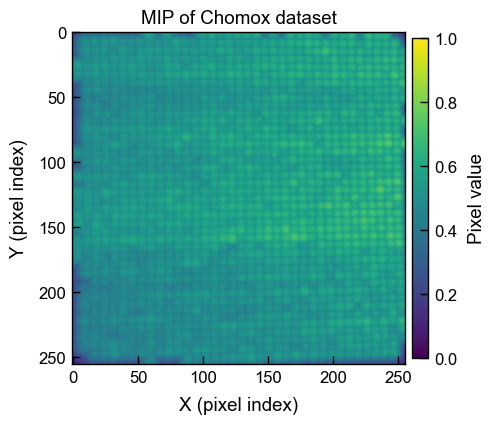

In [15]:
from xflow.utils.visualization import plot_image, stack_mip

sql_0 = """
    SELECT image_path
    FROM mmf_dataset_metadata
    WHERE purpose = 'testset'
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0;
"""

sql_1 = """
    SELECT image_path
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0;
"""

POSITION = 4  # 0 = 1st in group, 1 = 2nd, ..., 4 = 5th
sql_2 = f"""
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
)
SELECT image_path
FROM ordered
WHERE rn % 5 = {POSITION};
"""

# select training set building blocks. select from only the last three groups, and fliter out the boundary cases.
GT_SUM_MIN = 36000  # keep rows with ground_truth_stats_sum >= this value   good value 36000

sql_3 = f"""
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
),
candidates AS (
    SELECT
        image_path,
        rn,
        CAST(rn / 5 AS INTEGER) AS grp_id,
        (rn % 5) AS pos_in_grp,
        gt_sum
    FROM ordered
    WHERE (rn % 5) IN (2, 3, 4)
      AND gt_sum IS NOT NULL
      AND gt_sum >= {GT_SUM_MIN}
),
paired AS (
    -- keep only groups where 2,3,4 all survive threshold
    SELECT *
    FROM candidates
    WHERE grp_id IN (
        SELECT grp_id
        FROM candidates
        GROUP BY grp_id
        HAVING COUNT(*) = 3
    )
),
winner AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY grp_id
            ORDER BY gt_sum DESC, pos_in_grp DESC
        ) AS pick_rank
    FROM paired
)
SELECT
    image_path,
    gt_sum,
    grp_id,
    pos_in_grp
FROM winner
WHERE pick_rank = 1
ORDER BY grp_id;
"""



# select test set, same logic
GT_SUM_MIN = 36000  # keep rows with ground_truth_stats_sum >= this value   good value 36000

sql_4 = f"""
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'testset'
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
),
candidates AS (
    SELECT
        image_path,
        rn,
        CAST(rn / 5 AS INTEGER) AS grp_id,
        (rn % 5) AS pos_in_grp,
        gt_sum
    FROM ordered
    WHERE (rn % 5) IN (2, 3, 4)
      AND gt_sum IS NOT NULL
      AND gt_sum >= {GT_SUM_MIN}
),
paired AS (
    -- keep only groups where 2,3,4 all survive threshold
    SELECT *
    FROM candidates
    WHERE grp_id IN (
        SELECT grp_id
        FROM candidates
        GROUP BY grp_id
        HAVING COUNT(*) = 3
    )
),
winner AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY grp_id
            ORDER BY gt_sum DESC, pos_in_grp DESC
        ) AS pick_rank
    FROM paired
)
SELECT
    image_path,
    gt_sum,
    grp_id,
    pos_in_grp
FROM winner
WHERE pick_rank = 1
ORDER BY grp_id;
"""



# sample from the selected training set with a certain stride (e.g. keep 1 out of 3)
GT_SUM_MIN = 36000
STRIDE = 0 # 0 = keep all, 1 = keep every other, 2 = keep 1 out of 3, etc.

sql_5 = f"""
WITH ordered AS (
    SELECT
        image_id,
        image_path,
        ROW_NUMBER() OVER (ORDER BY CAST(image_id AS INTEGER) ASC) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
),
candidates AS (
    SELECT
        image_id,
        image_path,
        rn,
        CAST(rn / 5 AS INTEGER) AS grp_id,
        (rn % 5) AS pos_in_grp,
        gt_sum
    FROM ordered
    WHERE (rn % 5) IN (2, 3, 4)
      AND gt_sum IS NOT NULL
      AND gt_sum >= {GT_SUM_MIN}
),
paired AS (
    SELECT *
    FROM candidates
    WHERE grp_id IN (
        SELECT grp_id
        FROM candidates
        GROUP BY grp_id
        HAVING COUNT(*) = 3
    )
),
winner AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY grp_id
            ORDER BY gt_sum DESC, pos_in_grp DESC
        ) AS pick_rank
    FROM paired
),
final_sorted AS (
    SELECT
        image_id,
        image_path,
        gt_sum,
        grp_id,
        pos_in_grp,
        ROW_NUMBER() OVER (ORDER BY CAST(image_id AS INTEGER) ASC) - 1 AS out_idx
    FROM winner
    WHERE pick_rank = 1
)
SELECT
    image_id,
    image_path,
    gt_sum,
    grp_id,
    pos_in_grp
FROM final_sorted
WHERE out_idx % ({STRIDE} + 1) = 0
ORDER BY CAST(image_id AS INTEGER) ASC;
"""


# similar to above, but random sample with a certain ratio instead of fixed stride. e.g. 0.5 means keep 50% of the data, randomly selected.
GT_SUM_MIN = 36000
SAMPLE_RATIO = 0.3  # 0.0 to 1.0 (1.0 = 100%)

sql_6 = f"""
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
),
candidates AS (
    SELECT
        image_path,
        rn,
        CAST(rn / 5 AS INTEGER) AS grp_id,
        (rn % 5) AS pos_in_grp,
        gt_sum
    FROM ordered
    WHERE (rn % 5) IN (2, 3, 4)
      AND gt_sum IS NOT NULL
      AND gt_sum >= {GT_SUM_MIN}
),
paired AS (
    SELECT *
    FROM candidates
    WHERE grp_id IN (
        SELECT grp_id
        FROM candidates
        GROUP BY grp_id
        HAVING COUNT(*) = 3
    )
),
winner AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY grp_id
            ORDER BY gt_sum DESC, pos_in_grp DESC
        ) AS pick_rank
    FROM paired
),
final_table AS (
    SELECT
        image_path,
        gt_sum,
        grp_id,
        pos_in_grp
    FROM winner
    WHERE pick_rank = 1
),
sampled AS (
    SELECT *
    FROM final_table
    ORDER BY random()
    LIMIT (
        SELECT
            CASE
                WHEN {SAMPLE_RATIO} <= 0 THEN 0
                WHEN {SAMPLE_RATIO} >= 1 THEN COUNT(*)
                ELSE CAST(COUNT(*) * {SAMPLE_RATIO} AS INTEGER)
            END
        FROM final_table
    )
)
SELECT
    image_path,
    gt_sum,
    grp_id,
    pos_in_grp
FROM sampled
ORDER BY grp_id;
"""




# select test set: keep ALL chosen positions per group (no rank picking)
GT_SUM_MIN = 36000  # keep rows with ground_truth_stats_sum >= this value   good value 36000
POS_IN_GROUP = [1, 4]   # e.g. [0, 3], [2, 3, 4], etc.
pos_clause = ", ".join(str(i) for i in POS_IN_GROUP)

sql_7 = f"""
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'testset'
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
)
SELECT
    image_path,
    gt_sum,
    CAST(rn / 5 AS INTEGER) AS grp_id,
    (rn % 5) AS pos_in_grp
FROM ordered
WHERE (rn % 5) IN ({pos_clause})
  AND gt_sum IS NOT NULL
  AND gt_sum >= {GT_SUM_MIN}
ORDER BY grp_id, pos_in_grp;
"""




# based on the above selection logic, but further sample a subset based on poisson sampling?
sql_8 = """
WITH ordered AS (
    SELECT
        image_path,
        beam_settings,
        ground_truth_stats,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn
    FROM mmf_dataset_metadata
    WHERE purpose = 'testset'
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
),
filtered AS MATERIALIZED (
    SELECT
        image_path,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum,
        CAST(rn / 5 AS INTEGER) AS grp_id,
        (rn % 5) AS pos_in_grp,
        CAST(json_extract(REPLACE(beam_settings, char(39), '"'), '$.CLEAR_magnets.QFD0880') AS REAL) AS q1,
        CAST(json_extract(REPLACE(beam_settings, char(39), '"'), '$.CLEAR_magnets.QDD0515') AS REAL) AS q2,
        CAST(json_extract(REPLACE(beam_settings, char(39), '"'), '$.CLEAR_magnets.DHJ0840') AS REAL) AS q3,
        CAST(json_extract(REPLACE(beam_settings, char(39), '"'), '$.CLEAR_magnets.DVJ0840') AS REAL) AS q4,
        ROW_NUMBER() OVER (ORDER BY image_path) AS sample_rn
    FROM ordered
    WHERE (rn % 5) IN (1, 4)
      AND CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) >= 36000
)
SELECT image_path, gt_sum, grp_id, pos_in_grp
FROM filtered a
WHERE NOT EXISTS (
    SELECT 1 FROM filtered b
    WHERE b.sample_rn < a.sample_rn
      AND ((a.q1-b.q1)*(a.q1-b.q1)
        + (a.q2-b.q2)*(a.q2-b.q2)
        + (a.q3-b.q3)*(a.q3-b.q3)
        + (a.q4-b.q4)*(a.q4-b.q4)) < (0.5 * 0.5)
)
ORDER BY sample_rn
LIMIT 500;
"""





# the same as above but with pure random sampling.
sql_9 = """
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'testset'
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
),
filtered AS (
    SELECT
        image_path,
        gt_sum,
        CAST(rn / 5 AS INTEGER) AS grp_id,
        (rn % 5) AS pos_in_grp
    FROM ordered
    WHERE (rn % 5) IN (1, 4)
      AND gt_sum IS NOT NULL
      AND gt_sum >= 36000
)
SELECT image_path, gt_sum, grp_id, pos_in_grp
FROM filtered
ORDER BY (ROW_NUMBER() OVER (ORDER BY image_path) * 2654435761) % 4294967296
LIMIT 400;
"""




# select test set: keep ALL chosen positions per group (no rank picking) but with non cropped data, so intensity summation should be removed.
POS_IN_GROUP = [4]   # e.g. [0, 3], [2, 3, 4], etc.
pos_clause = ", ".join(str(i) for i in POS_IN_GROUP)

sql_10 = f"""
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'testset'
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
)
SELECT
    image_path,
    gt_sum,
    CAST(rn / 5 AS INTEGER) AS grp_id,
    (rn % 5) AS pos_in_grp
FROM ordered
WHERE (rn % 5) IN ({pos_clause})
ORDER BY grp_id, pos_in_grp;
"""




# select training set building blocks without GT_SUM_MIN threshold filter
sql_11 = """
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
),
candidates AS (
    SELECT
        image_path,
        rn,
        CAST(rn / 5 AS INTEGER) AS grp_id,
        (rn % 5) AS pos_in_grp,
        gt_sum
    FROM ordered
    WHERE (rn % 5) IN (2, 3, 4)
),
paired AS (
    -- keep only groups where positions 2,3,4 all exist
    SELECT *
    FROM candidates
    WHERE grp_id IN (
        SELECT grp_id
        FROM candidates
        GROUP BY grp_id
        HAVING COUNT(*) = 3
    )
),
winner AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY grp_id
            ORDER BY gt_sum DESC, pos_in_grp DESC
        ) AS pick_rank
    FROM paired
)
SELECT
    image_path,
    gt_sum,
    grp_id,
    pos_in_grp
FROM winner
WHERE pick_rank = 1
ORDER BY grp_id;
"""


provider_path = config["paths"]["processed_chromox_cropped"]  # processed_chromox_cropped  processed_chromox
provider_db_path = provider_path + config["dataset_structure"]["db"] 

provider = SqlProvider(
    sources={"connection": provider_db_path, "sql": sql_3},  # sql_11. sql_3
    output_config={'list': "image_path"}
)#.subsample(n_samples=10000, seed=config["seed"])

config["data"]["transforms"]["torch"].insert(0, {
    "name": "add_parent_dir",
    "params": {
        "parent_dir": provider_path
    }
})
transforms = build_transforms_from_config(config["data"]["transforms"]["torch"])

data_pipeline = PyTorchPipeline(
    provider, 
    transforms,
).to_numpy() 

mip = stack_mip(data_pipeline[1])
plot_image(mip, title=f"MIP of Chomox dataset", cmap="viridis", scale="linear", vmin=0, vmax=1) # inferno, viridis, plasma, magma, gray,  vmin=0, vmax=1

# Save MIP (decoupled)
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from datetime import datetime
from pathlib import Path
from xflow.extensions.style.aps import set_aps_double_column as set_aps_style
_d = Path(dirs["temp_save_to"]); _d.mkdir(parents=True, exist_ok=True)
set_aps_style(scale=1.8)
_fig, _ax = plt.subplots(figsize=(4, 4))
_im = _ax.imshow(mip.squeeze(), cmap="viridis", vmin=0, vmax=1)
_ax.set_xticks([]); _ax.set_yticks([])
_cax = make_axes_locatable(_ax).append_axes("right", size="5%", pad=0.05)
_fig.colorbar(_im, cax=_cax)
_fig.savefig(_d / f"{datetime.now().strftime('%Y%m%d_%H%M%S_%f')}.pdf", bbox_inches="tight", transparent=True)
plt.close(_fig)

In [ ]:
from pathlib import Path
import shutil

def copy_relative_files(paths, provider_path, out_dir="results/check"):
    base = Path(provider_path)
    out_root = Path(out_dir)
    copied, missing = [], []

    for rel in paths:
        rel_path = Path(rel)                  # e.g. dataset/1763....png
        src = base / rel_path                 # provider_path + relative path
        dst = out_root / rel_path             # keep relative structure under results/check/

        if src.is_file():
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)
            copied.append(str(dst))
        else:
            missing.append(str(src))

    return copied, missing

copied, missing = copy_relative_files(provider(), provider_path, out_dir="results/check")

# Fiber coupling map visualization

In [ ]:
"""use DMD position scan of each experiment to visulize each setup coupling quality"""

import numpy as np
import matplotlib.pyplot as plt

def coupling_map(data_pipeline, dim=(32, 32), mode="input_over_label", eps=1e-12, output_scale=1.0):
    h, w = dim
    n = h * w

    arr = np.asarray(data_pipeline, dtype=np.float32)
    if arr.ndim != 5 or arr.shape[0] != 2:
        raise ValueError(f"Expected shape (2, N, C, H, W), got {arr.shape}")
    if arr.shape[1] < n:
        raise ValueError(f"Need {n} samples, only got {arr.shape[1]}")

    pair_sums = arr[:, :n].reshape(2, n, -1).sum(axis=-1)
    input_sum = pair_sums[0]
    label_sum = pair_sums[1]

    if mode == "input_over_label":
        ratio = input_sum / (label_sum + eps)
    elif mode == "label_over_input":
        ratio = label_sum / (input_sum + eps)
    else:
        raise ValueError("mode must be input_over_label or label_over_input")

    return ratio.reshape(h, w) * float(output_scale)

def plot_coupling_map(cmap, title="Coupling Map", cmap_name="inferno"):
    plt.figure(figsize=(6, 6))
    im = plt.imshow(cmap, cmap=cmap_name, origin="upper")
    plt.colorbar(im, label="coupling ratio")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()

dataset = "2025-11-06"  # processed_dmd, 2025-11-06

if dataset == "processed_dmd":
    sql = config["sql"]["clear_dmd_position_basis"]
    scale_factor = 1.0
elif dataset == "2025-11-06":
    sql = config["sql"]["2025-11-06_train"]
    scale_factor = 0.159
    
provider_path = config["paths"][dataset]  # processed_dmd, 2025-11-06
provider_db_path = provider_path + config["dataset_structure"]["db"] 

provider = SqlProvider(
    sources={"connection": provider_db_path, "sql": sql},  # 
    output_config={'list': "image_path"}
)#.subsample(n_samples=10000, seed=config["seed"])

config["data"]["transforms"]["torch"].insert(0, {
    "name": "add_parent_dir",
    "params": {
        "parent_dir": provider_path
    }
})
transforms = build_transforms_from_config(config["data"]["transforms"]["torch"])

data_pipeline = PyTorchPipeline(
    provider, 
    transforms,
).to_numpy() 

# usage
cmap = coupling_map(data_pipeline, dim=(32, 32), mode="input_over_label", output_scale=scale_factor)
plot_image(cmap, title=f"Coupling Map of {dataset}", cmap="inferno")

In [ ]:
# cross check with precalcuated coupling ratio in the database
# provider() gives coupling_ratio list directly
def coupling_map_from_provider(provider, dim=(32, 32)):
    h, w = dim
    n = h * w
    ratios = np.asarray(provider(), dtype=np.float32).reshape(-1)

    if ratios.size < n:
        raise ValueError(f"Need {n} ratios, got {ratios.size}")

    return ratios[:n].reshape(h, w)

dataset = "processed_dmd" 
sql_0 = """
    SELECT coupling_ratio
    FROM mmf_dataset_metadata
    WHERE experiment_description = 'position based coupling intensity'
      AND purpose = 'intensity_position'
      AND batch IN (9)
"""
provider_path = config["paths"][dataset]  # processed_dmd, 2025-11-06
provider_db_path = provider_path + config["dataset_structure"]["db"] 

provider = SqlProvider(
    sources={"connection": provider_db_path, "sql": sql_0},  # 
    output_config={'list': "coupling_ratio"}
)#.subsample(n_samples=10000, seed=config["seed"])

# usage
cmap_db = coupling_map_from_provider(provider, dim=(32, 32))
plot_image(cmap_db, title="Coupling Map from DB", cmap="inferno")

# Check Chromox kernal scan basis + SGM

## 1. Index based basis + SGM

In [ ]:
from dirs import *
from pathlib import Path
from copy import deepcopy
import random
import numpy as np
from tqdm import tqdm

from xflow import SqlProvider, TransformRegistry as T
from xflow.data import build_transforms_from_config
from xflow.utils.visualization import plot_image
from xflow.extensions.physics.pipeline import CachedBasisPipeline, IndexCombinator
from xflow.extensions.physics import pattern_gen
from config_utils import load_config

experiment_name = "CLEAR_visualization"
config = load_config(
    f"{experiment_name}.yaml",
    machine=machine,
)

# REPLACE THESE
DATASET_PATH_KEY = "processed_chromox_cropped"   # e.g. processed_dmd
ORTH_SQL_KEY = "processed_chromox_cropped_line_scan"  # e.g. train or lab_dmd_orth
SYNTH_TAKE_N = 1000

root_dir = Path(config["paths"][DATASET_PATH_KEY])
db_rel = config["dataset_structure"]["db"].lstrip("/\\")
db_path = str(root_dir / db_rel)
orth_sql = config["sql"][ORTH_SQL_KEY]


class PatternTap:
    def __init__(self):
        self.last = None

    def __call__(self, sample):
        self.last = np.asarray(sample).copy()
        return sample


def build_sgm_stream(cfg, tap_before_postprocess=None):
    canvas = pattern_gen.DynamicPatterns(*cfg["simulation"]["canvas_size"])

    post_fns = build_transforms_from_config(cfg["simulation"]["process_functions"])
    if tap_before_postprocess is not None:
        post_fns = [tap_before_postprocess, *post_fns]
    canvas.set_postprocess_fns(post_fns)

    canvas._distributions = [
        pattern_gen.StaticGaussianDistribution(canvas)
        for _ in range(cfg["simulation"]["total_Guassian_num"])
    ]
    canvas.set_threshold(cfg["simulation"]["minimum_pixel_threshold"])
    return canvas.pattern_stream(
        std_1=cfg["simulation"]["std_1"],
        std_2=cfg["simulation"]["std_2"],
        max_intensity=cfg["simulation"]["max_intensity"],
        fade_rate=cfg["simulation"]["fade_rate"],
        distribution=cfg["simulation"]["distribution"],
    )


def resize_map_to_hw(m, out_h, out_w):
    m = np.asarray(m, dtype=np.float32)
    h, w = m.shape

    if (h, w) == (out_h, out_w):
        return m

    if out_h % h == 0 and out_w % w == 0:
        sy, sx = out_h // h, out_w // w
        return np.repeat(np.repeat(m, sy, axis=0), sx, axis=1)

    y_idx = np.floor(np.arange(out_h) * (h / out_h)).astype(np.int64)
    x_idx = np.floor(np.arange(out_w) * (w / out_w)).astype(np.int64)
    y_idx = np.clip(y_idx, 0, h - 1)
    x_idx = np.clip(x_idx, 0, w - 1)
    return m[y_idx][:, x_idx]


def to_single_channel_01(arr, fallback_hw):
    if arr is None:
        return np.zeros((1, fallback_hw[0], fallback_hw[1]), dtype=np.float32)

    x = np.asarray(arr, dtype=np.float32)
    if x.ndim == 2:
        x = x[None, :, :]
    elif x.ndim == 3:
        if x.shape[0] in (1, 3):         # CHW
            x = x[:1]
        elif x.shape[-1] in (1, 3):      # HWC
            x = np.moveaxis(x, -1, 0)[:1]
        else:
            return np.zeros((1, fallback_hw[0], fallback_hw[1]), dtype=np.float32)
    else:
        return np.zeros((1, fallback_hw[0], fallback_hw[1]), dtype=np.float32)

    if x.max() > 1.0:
        x = x / 255.0
    return np.clip(x, 0.0, 1.0).astype(np.float32)


orth_provider = SqlProvider(
    sources={"connection": db_path, "sql": orth_sql},
    output_config={"list": "image_path"},
)

transform_cfg = [
    {"name": "add_parent_dir", "params": {"parent_dir": str(root_dir)}},
    *deepcopy(config["data"]["transforms"]["torch"]),
]
full_transforms = build_transforms_from_config(transform_cfg)

tap_raw_pattern = PatternTap()

combinator = IndexCombinator(
    pattern_provider=build_sgm_stream(config, tap_before_postprocess=tap_raw_pattern),
    transforms=build_transforms_from_config(config["combinator"]["transforms"]["torch"]),
)

train_dataset = CachedBasisPipeline(
    orth_provider,
    combinator=combinator,
    transforms=full_transforms,
    num_samples=config["data"]["total_train_samples"],
    seed=config["seed"],
    eager=True,
)

it = iter(train_dataset)

pair_list = []                # each: (2, 1, H, W)
pattern_coeff_list = []       # each: (1, H, W), map actually used by combinator
pattern_raw_native_list = []  # each: (1, h0, w0), native/high-res before process_functions
pattern_raw_plot_list = []    # each: (1, H, W), resized only for side-by-side plotting

for _ in tqdm(range(SYNTH_TAKE_N)):
    pair = np.asarray(next(it), dtype=np.float32)  # (2, 1, H, W)
    pair_list.append(pair)

    H, W = pair.shape[-2], pair.shape[-1]

    coeff_map = np.asarray(combinator.last_coeff_map, dtype=np.float32)  # (h, w)
    coeff_map = resize_map_to_hw(coeff_map, H, W)                        # (H, W)
    coeff_map = coeff_map[None, :, :]                                    # (1, H, W)
    pattern_coeff_list.append(coeff_map)

    raw_native = to_single_channel_01(tap_raw_pattern.last, fallback_hw=(H, W))
    pattern_raw_native_list.append(raw_native)

    if raw_native.shape[-2:] != (H, W):
        raw_plot = resize_map_to_hw(raw_native[0], H, W)[None, :, :]
    else:
        raw_plot = raw_native
    pattern_raw_plot_list.append(raw_plot.astype(np.float32))

# (2, N, 1, H, W)
samples_pair = np.stack(pair_list, axis=0)
samples_pair = np.transpose(samples_pair, (1, 0, 2, 3, 4))

# (1, N, 1, H, W)
samples_pattern_coeff = np.stack(pattern_coeff_list, axis=0)
samples_pattern_coeff = np.expand_dims(samples_pattern_coeff, axis=0)

# (1, N, 1, H, W)
samples_pattern_raw_plot = np.stack(pattern_raw_plot_list, axis=0)
samples_pattern_raw_plot = np.expand_dims(samples_pattern_raw_plot, axis=0)

# Keep old format
samples = np.concatenate([samples_pair, samples_pattern_coeff], axis=0)  # (3, N, 1, H, W)

# New plot-ready format
samples_plot4 = np.concatenate(
    [samples_pair, samples_pattern_coeff, samples_pattern_raw_plot], axis=0
)  # (4, N, 1, H, W)

print("samples shape (left/right/coeff):", samples.shape)
print("samples_plot4 shape (left/right/coeff/raw_plot):", samples_plot4.shape)
print("raw native list length:", len(pattern_raw_native_list))

# Plot
n_show = min(10, SYNTH_TAKE_N)
indexs = random.sample(range(SYNTH_TAKE_N), n_show)
for i in indexs:
    a = samples_plot4[0, i]  # left
    b = samples_plot4[1, i]  # right
    c = samples_plot4[2, i]  # coeff map used by combinator
    d = samples_plot4[3, i]  # raw native pattern resized for join

    joined_image = T.get("join_image")([a, b, c, d], layout=(1, 4))
    plot_image(
        joined_image,
        title="Sample synthetic image: left | right | coeff | raw(resized)",
        cmap="inferno",
        scale="linear",
        vmin=0,
        vmax=1,
    )

## 2. position (center of mass nearest neighbor based) combinator logic + SGM

[config_utils] Using machine profile: mac-andrewxu
--------------------------------------------------------------------------------
Connected to SQLite database with 1 tables
--------------------------------------------------------------------------------


Caching basis:   0%|          | 0/1503 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:01<00:00, 37.41it/s]


samples shape (left/right/coeff): (3, 50, 1, 256, 256)
samples_plot4 shape (left/right/coeff/raw_plot): (4, 50, 1, 256, 256)
raw native patterns stored as list length: 50


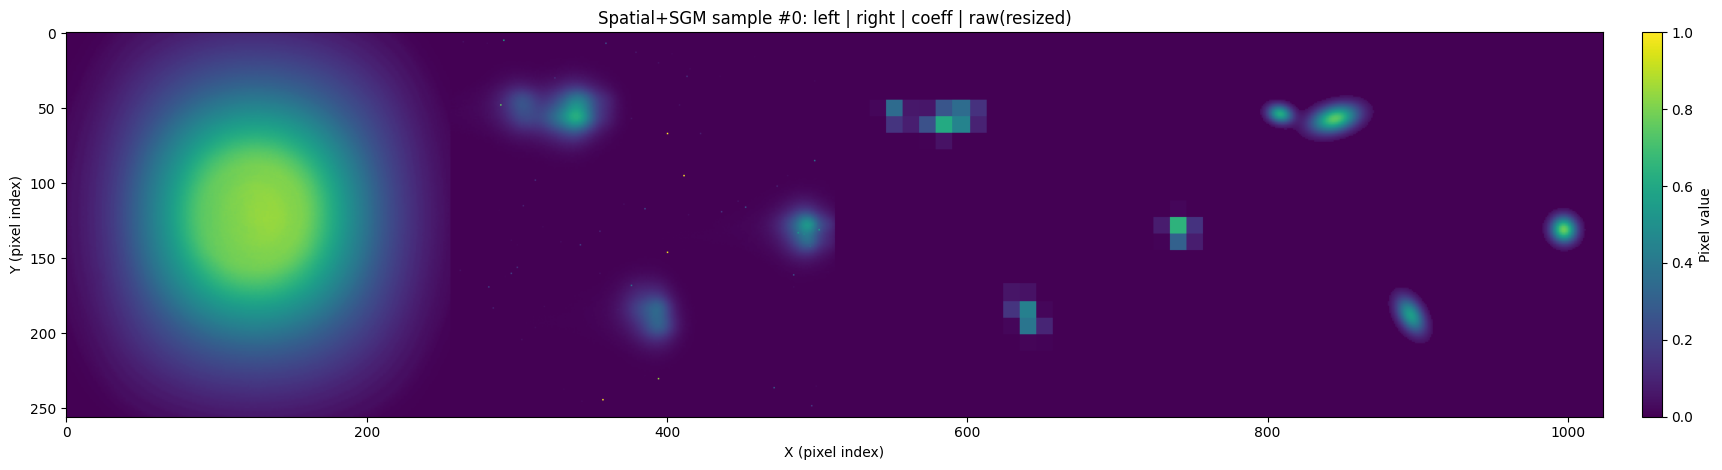

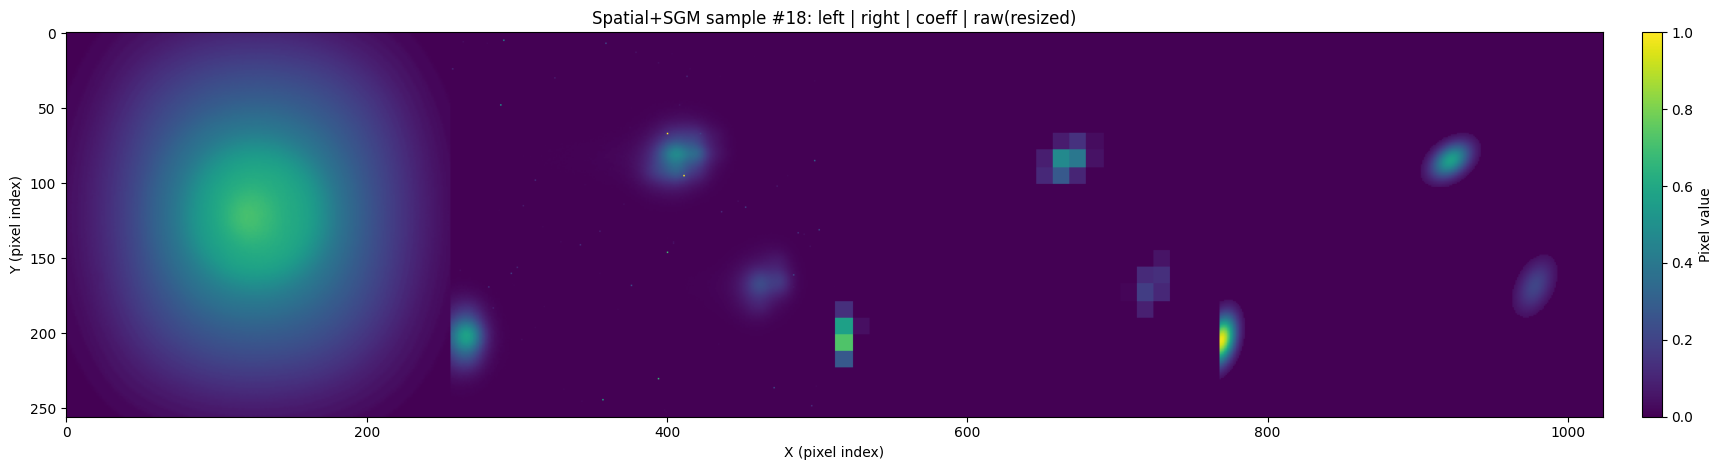

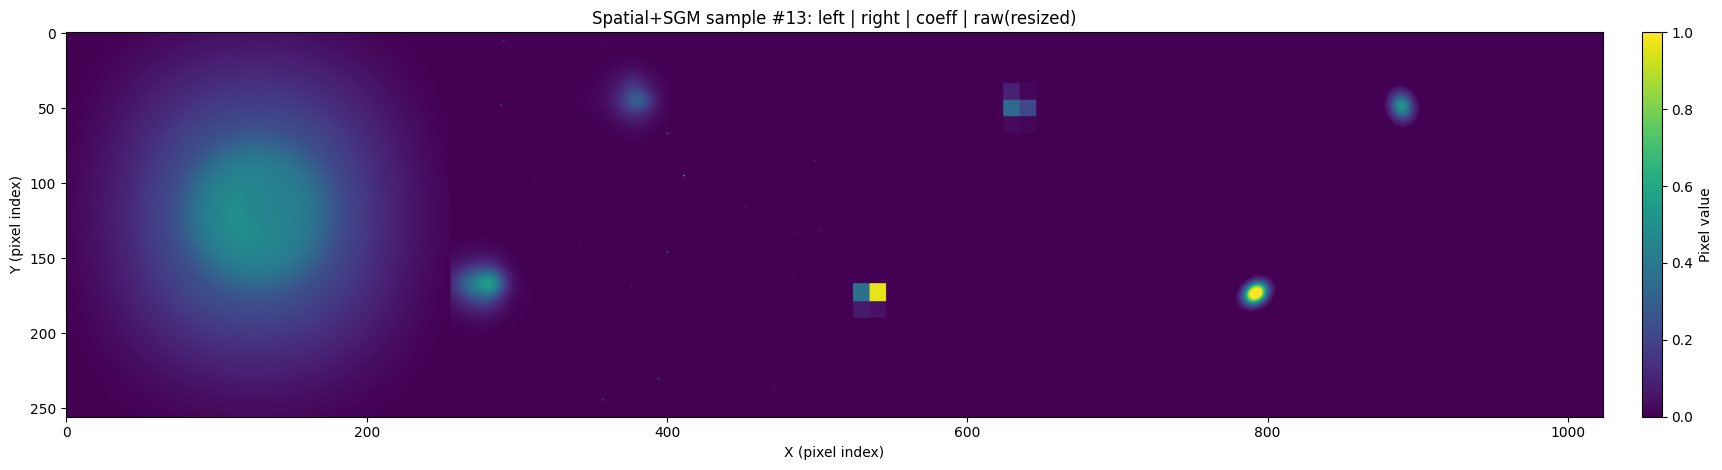

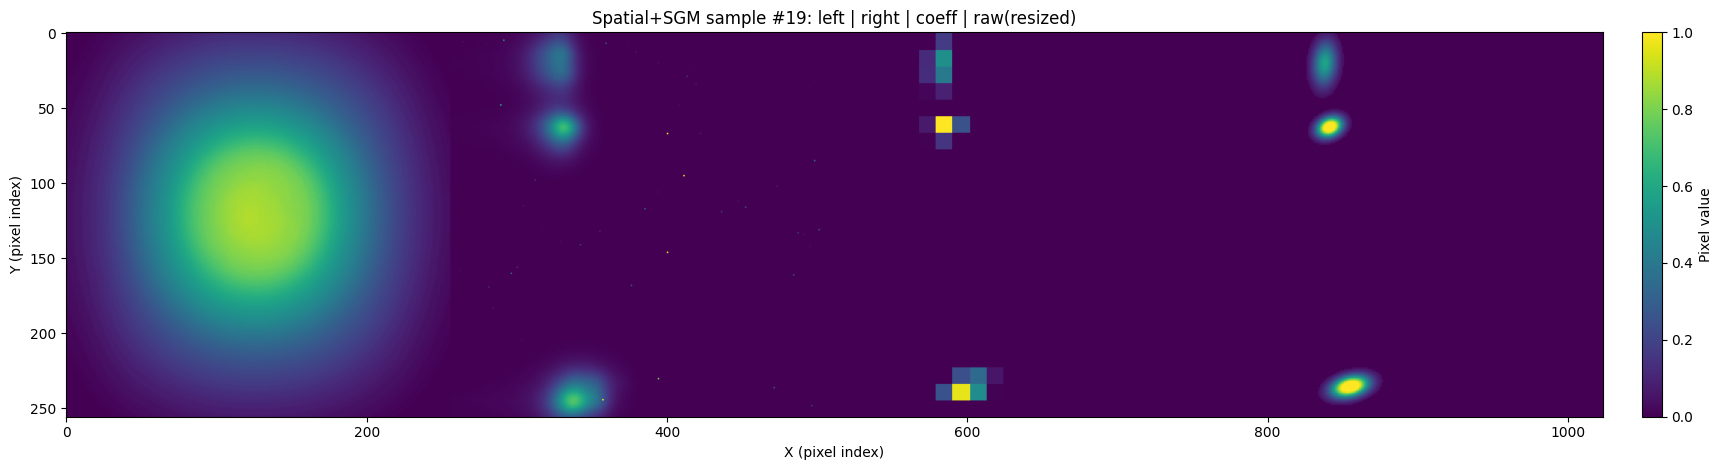

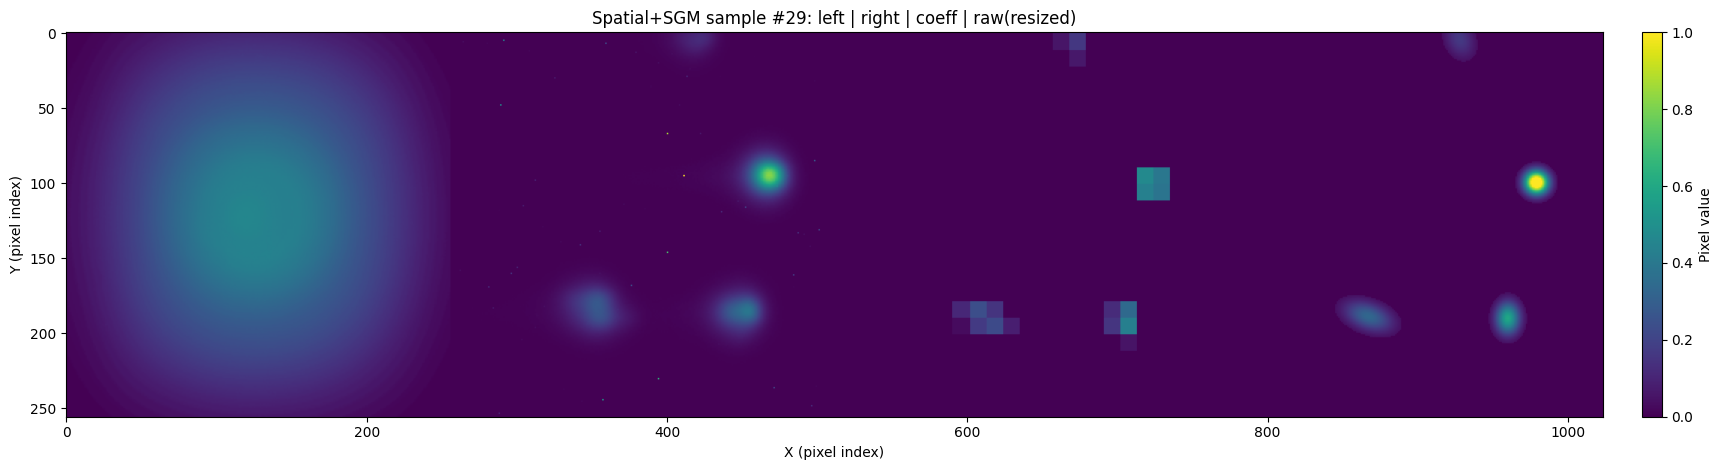

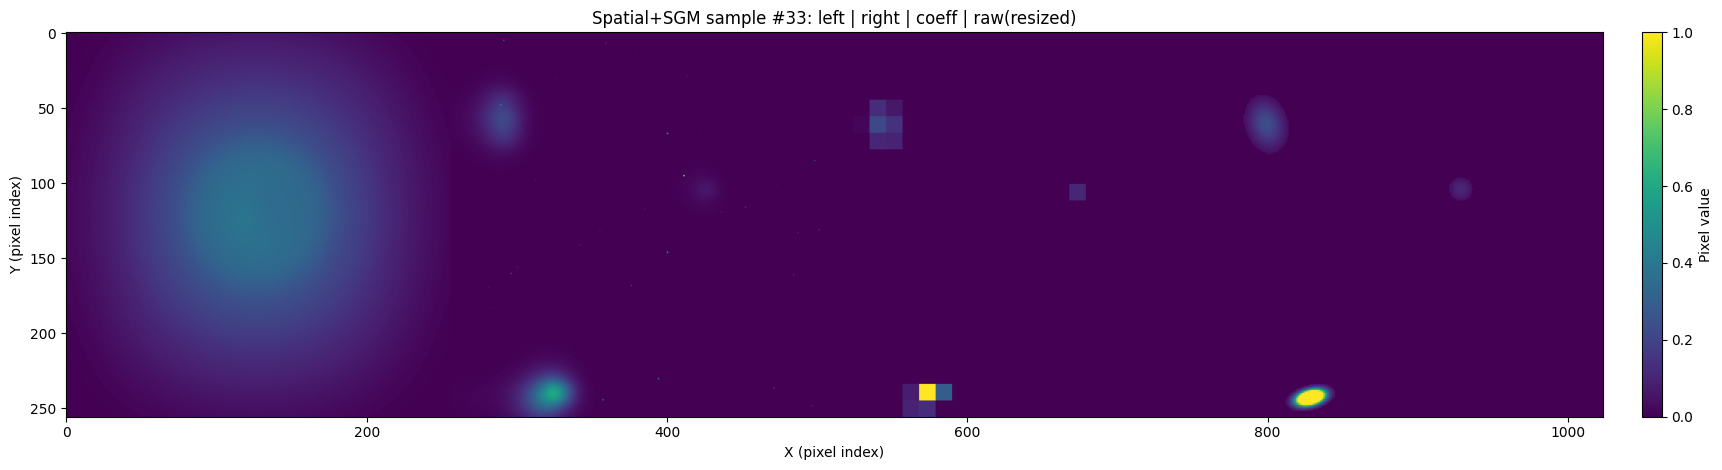

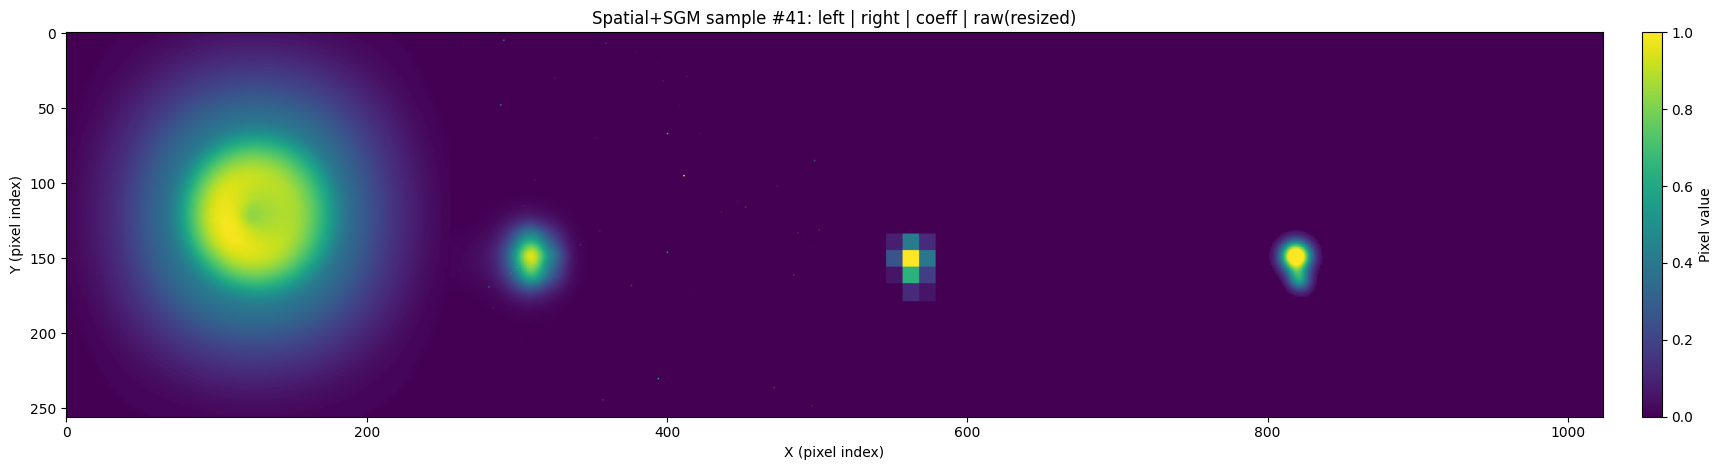

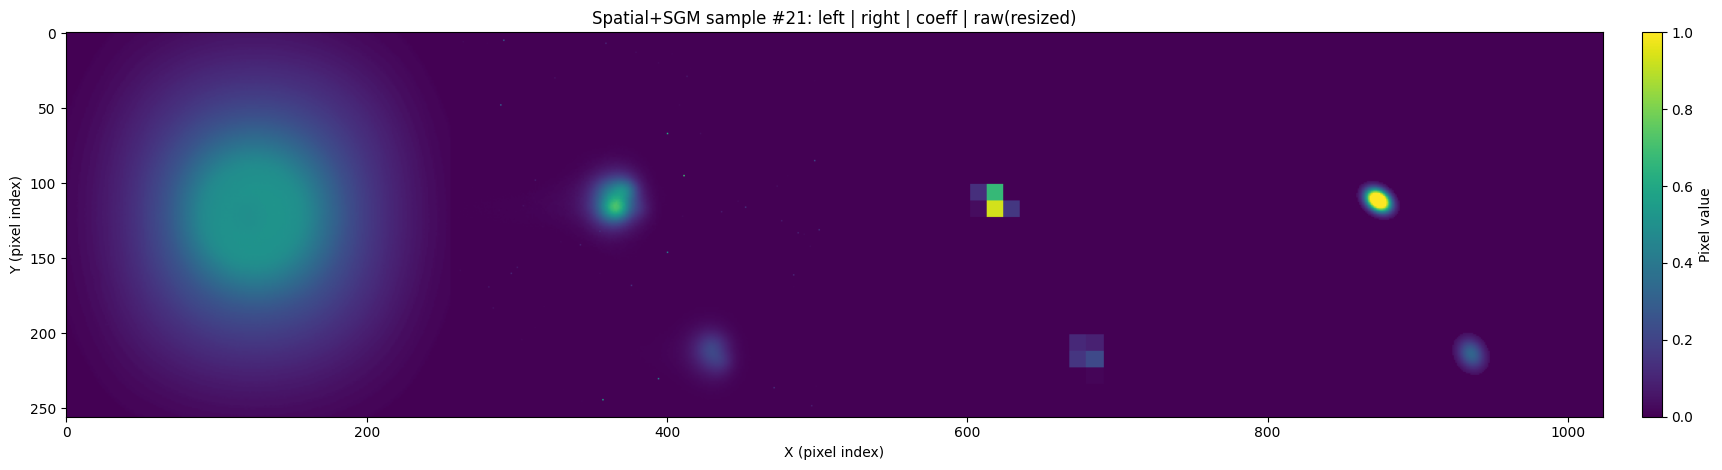

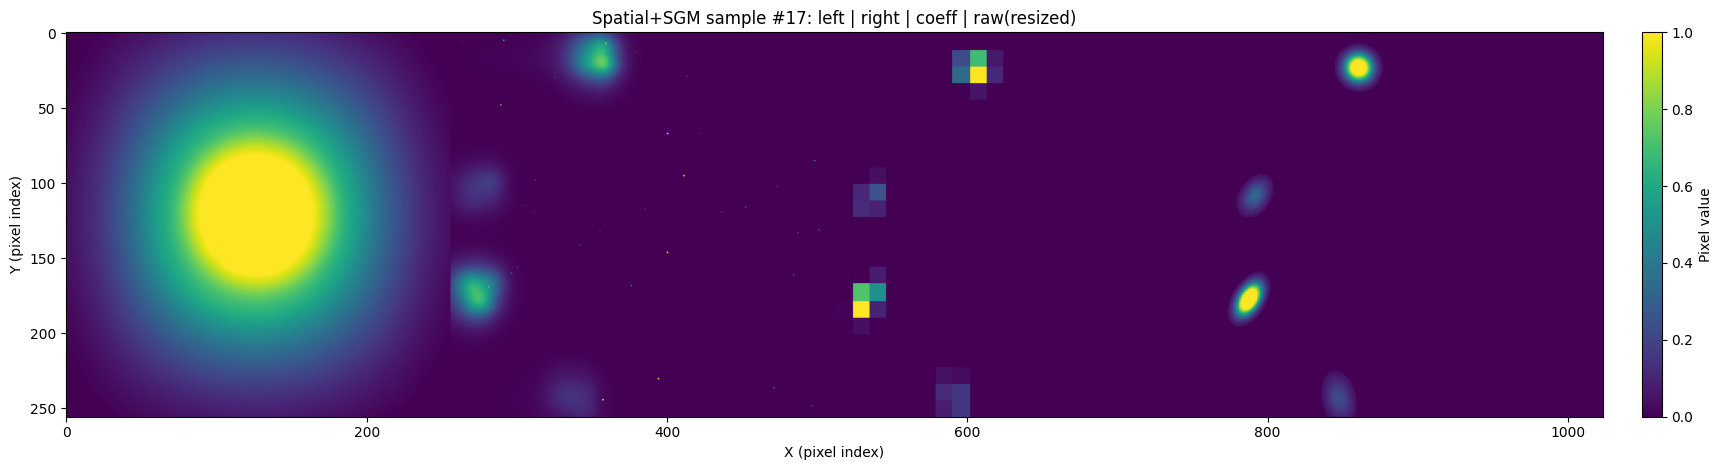

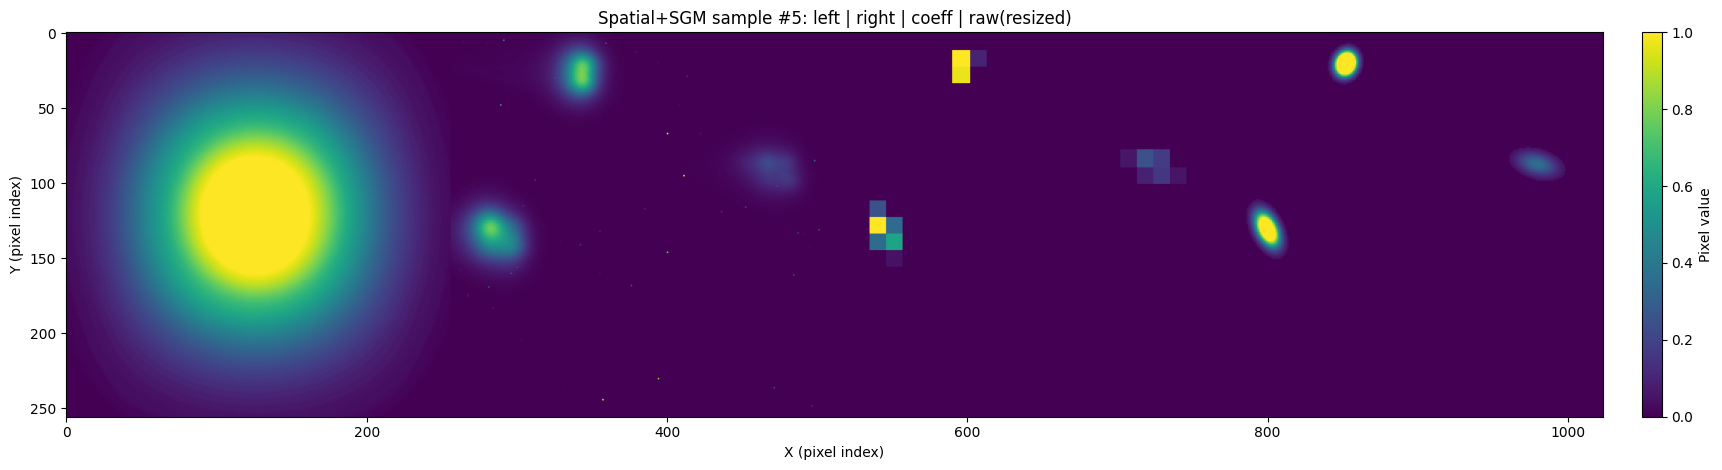

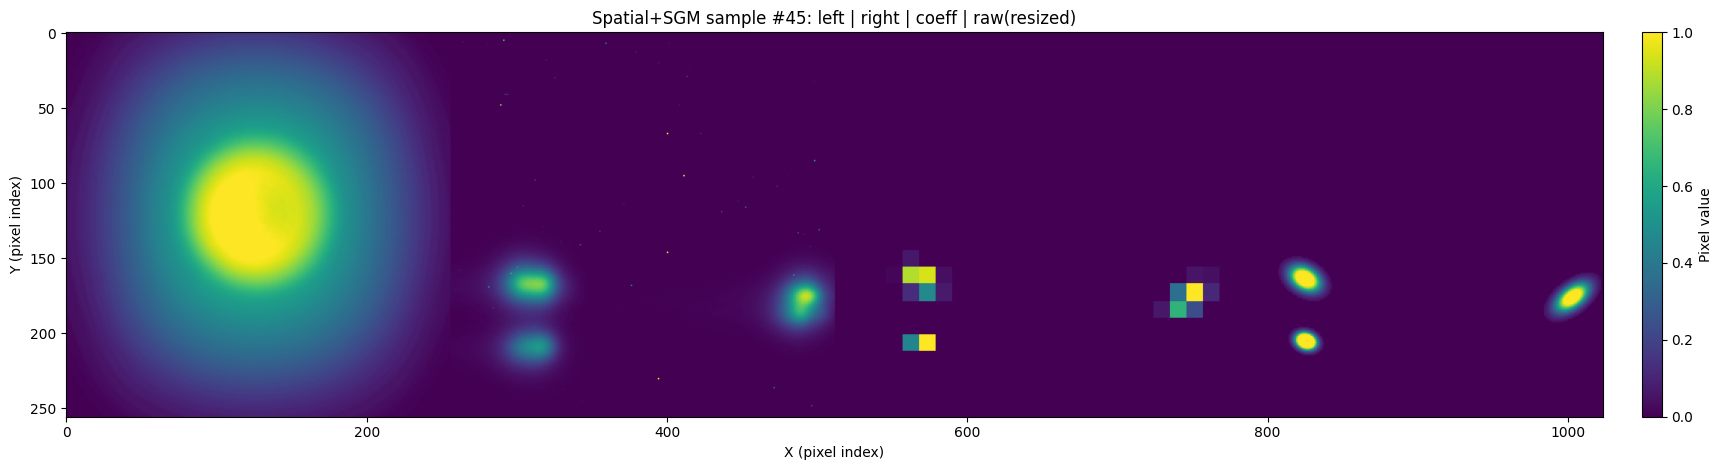

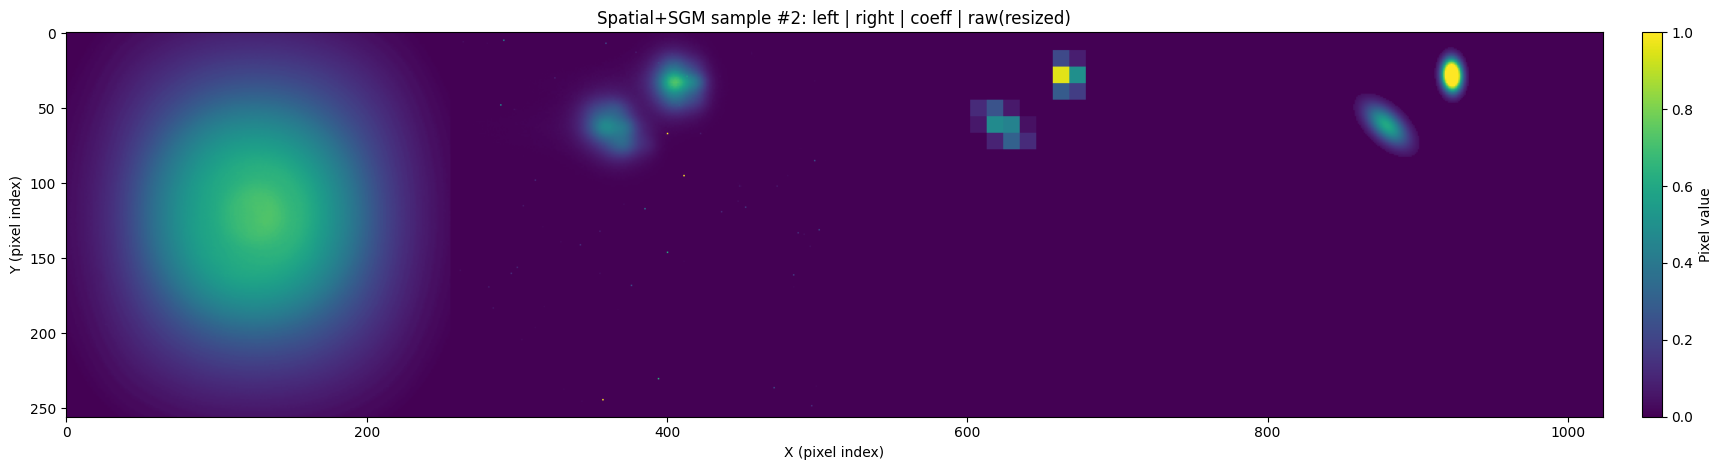

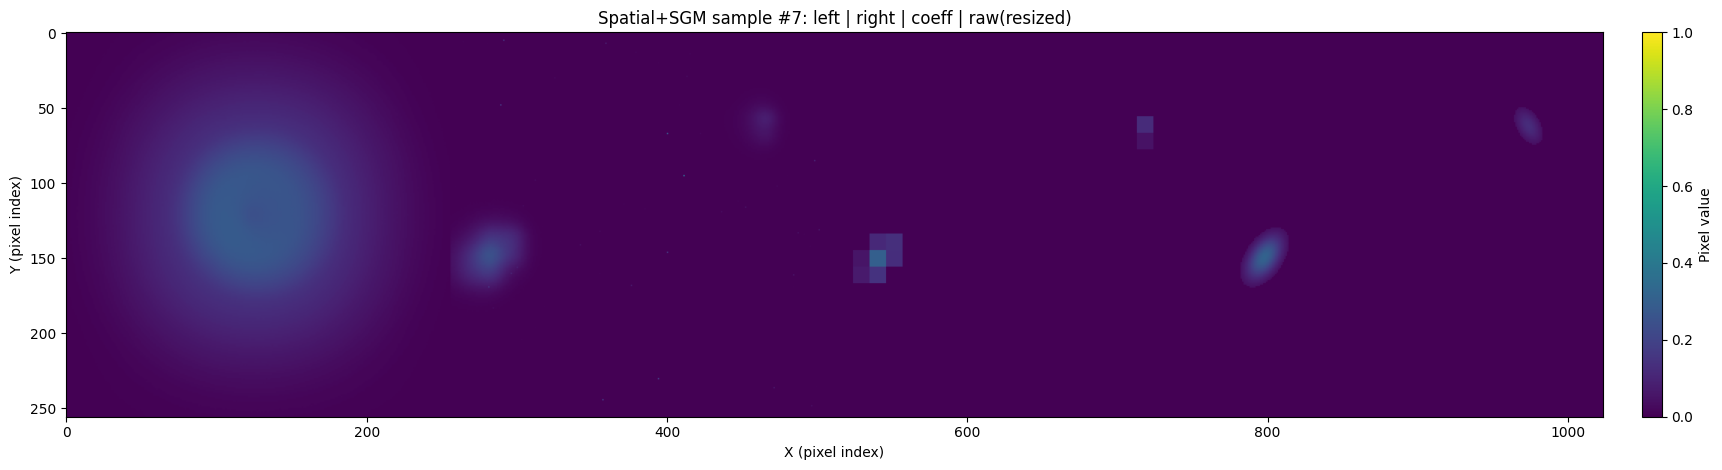

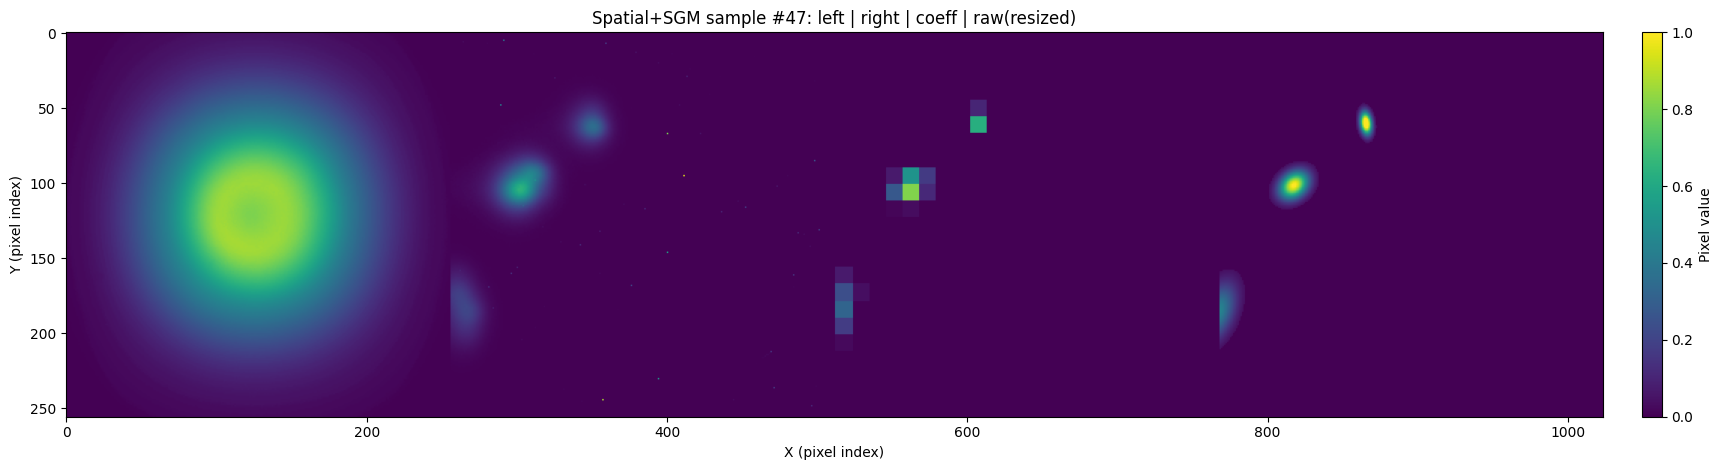

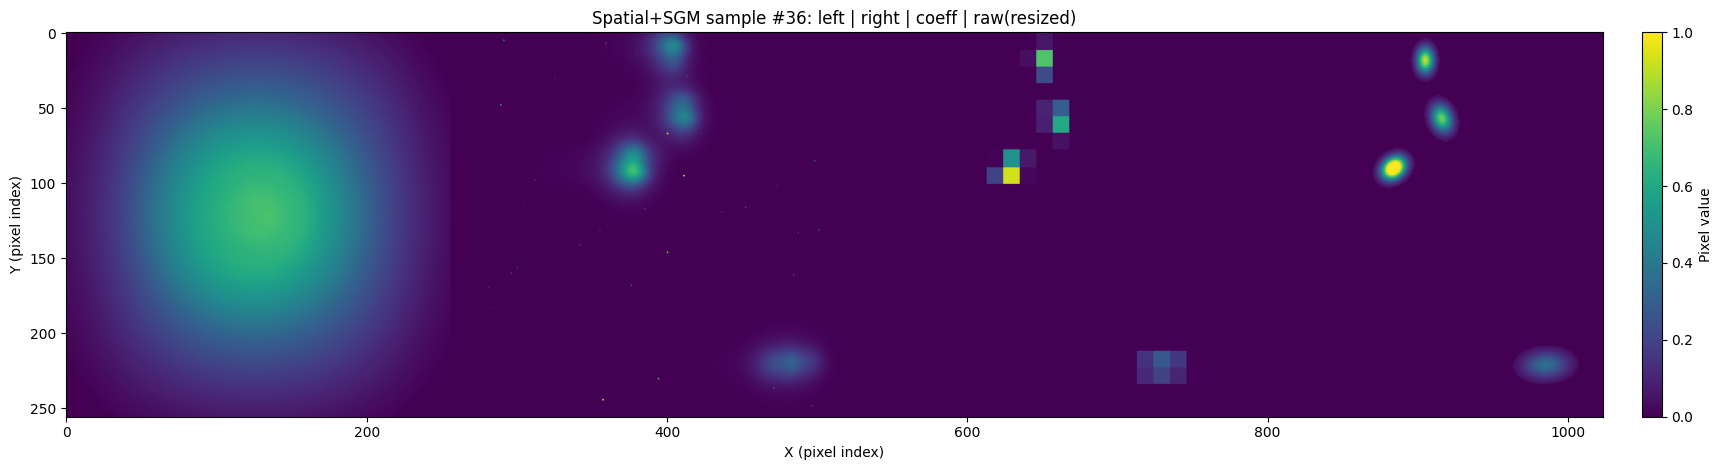

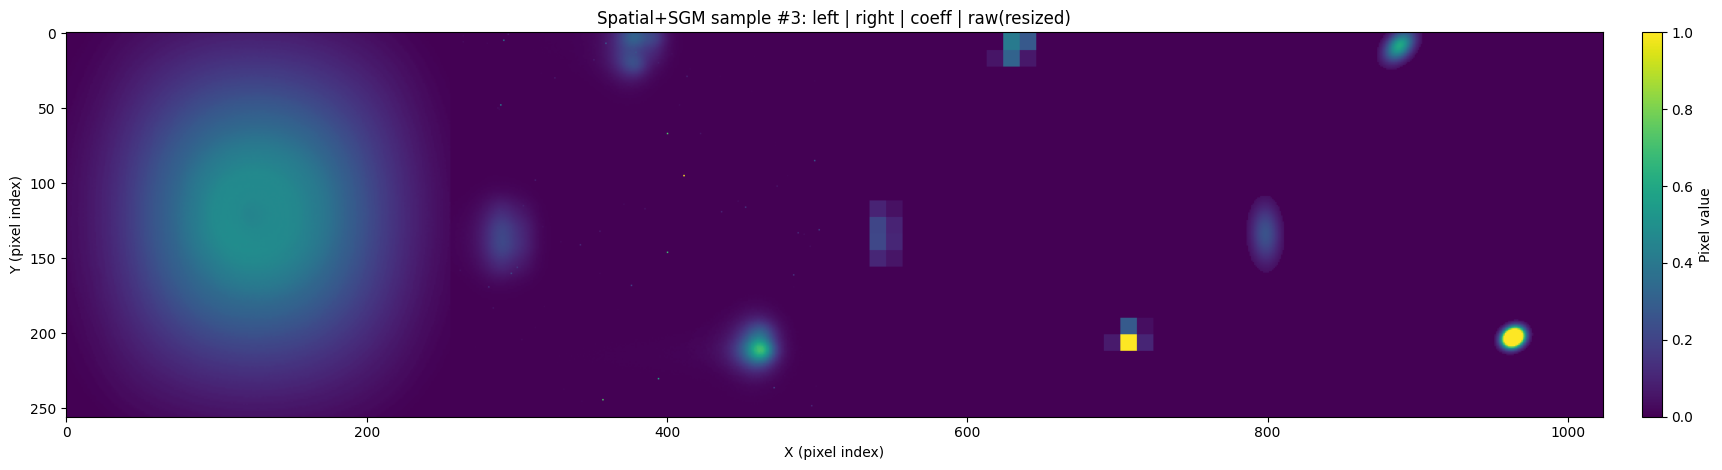

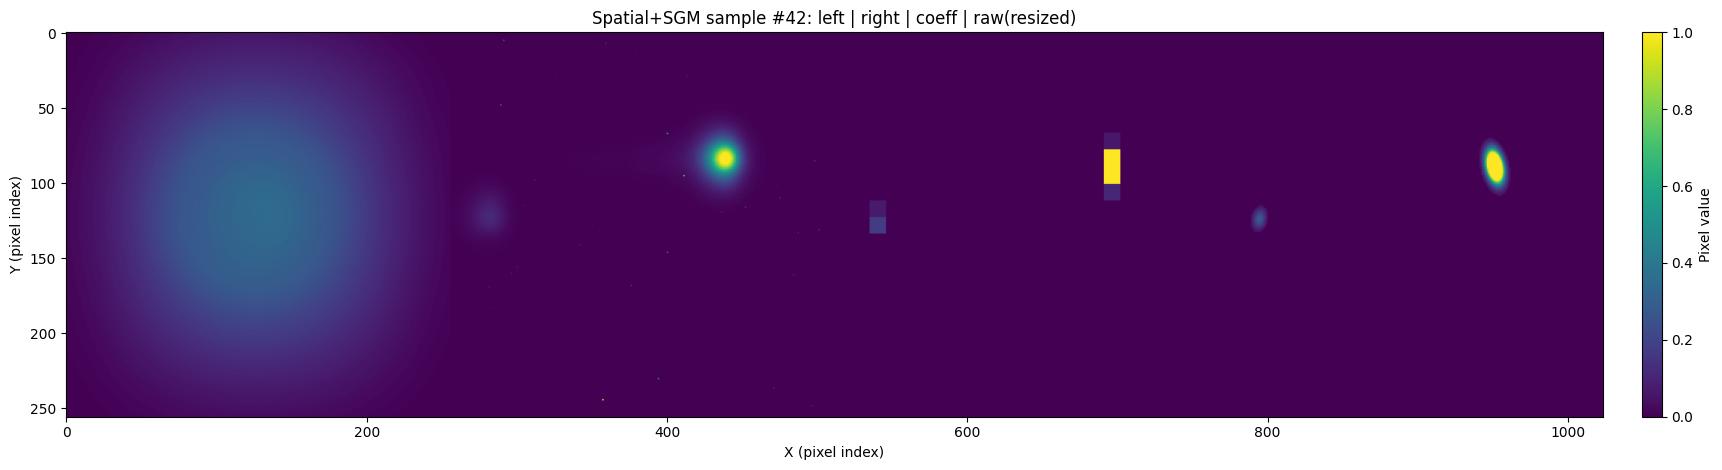

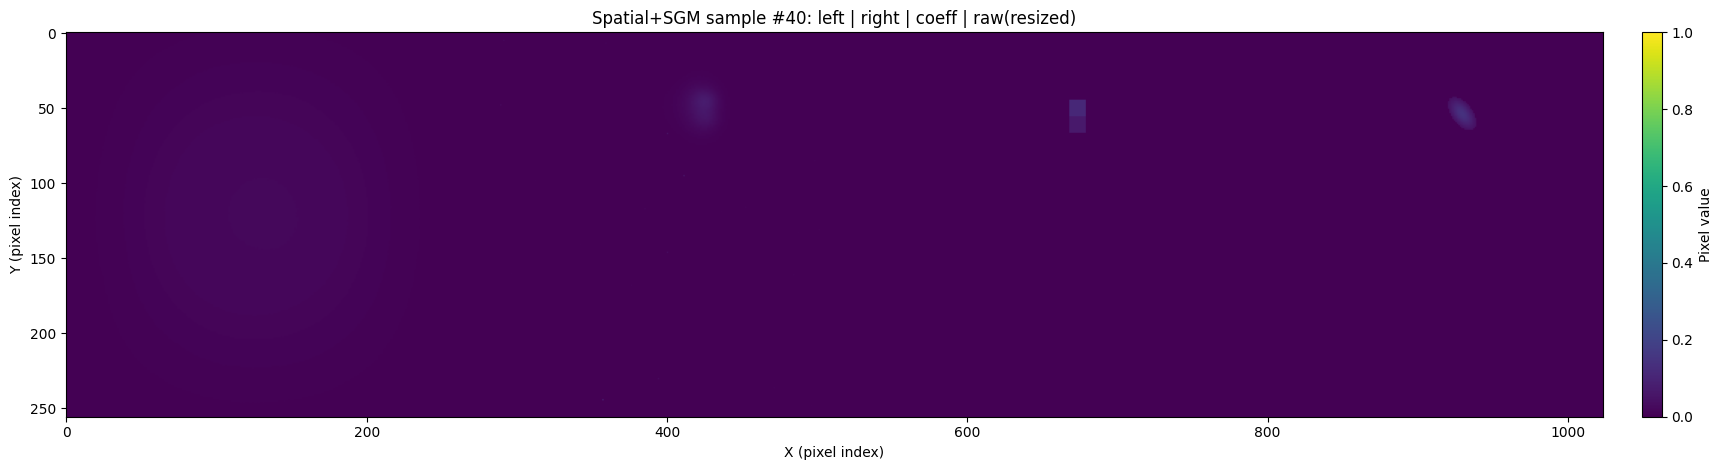

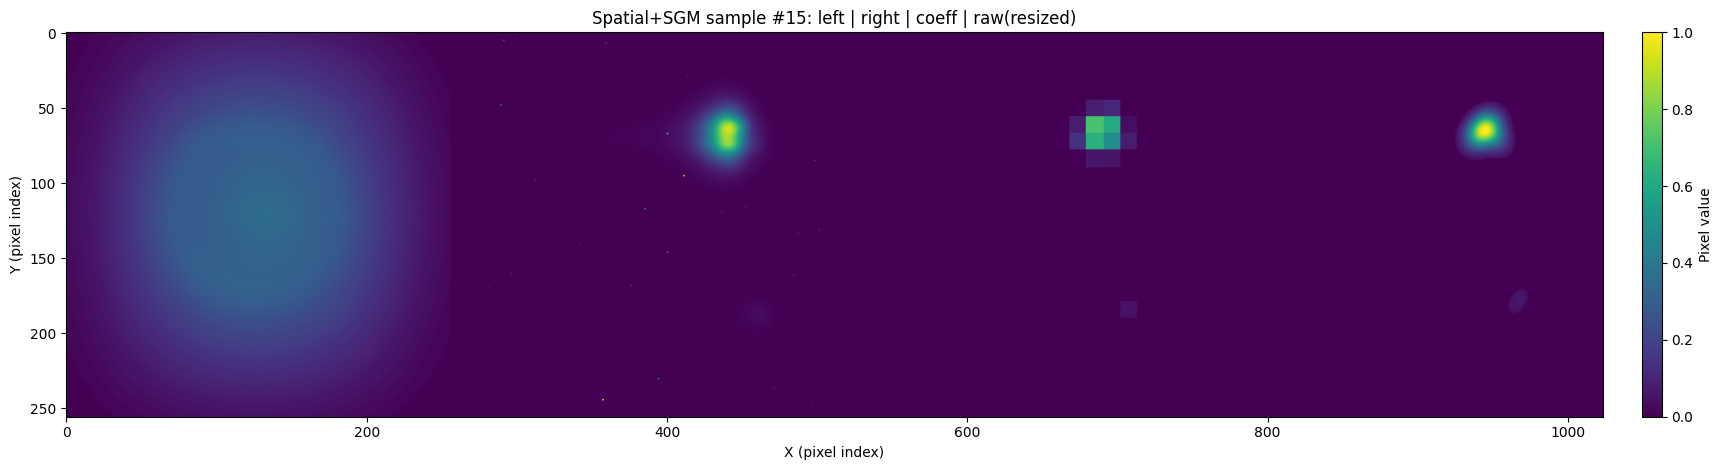

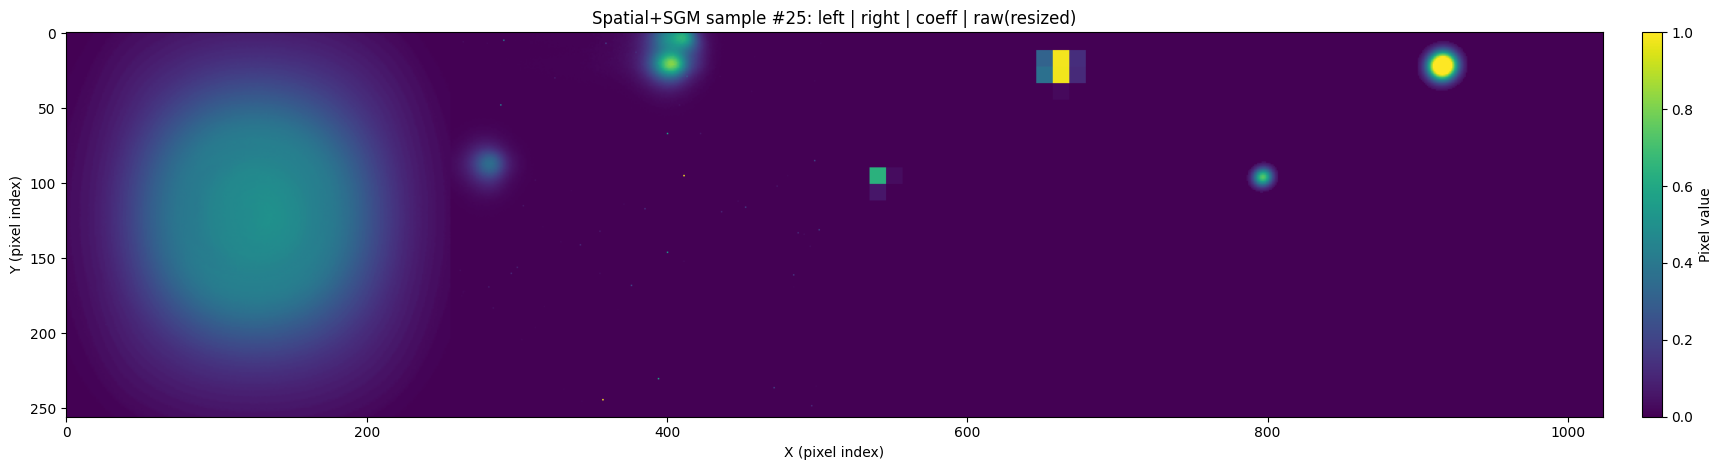

In [3]:
from dirs import *
from pathlib import Path
from copy import deepcopy
from datetime import datetime
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from xflow import SqlProvider, TransformRegistry as T
from xflow.data import build_transforms_from_config
from xflow.utils.visualization import plot_image
from xflow.extensions.physics.pipeline import (
    CachedBasisPipeline,
    SpatialNearestCombinator,
    make_centroid_position_extractor,
)
from xflow.extensions.physics import pattern_gen
from config_utils import load_config

experiment_name = "CLEAR_visualization"
config = load_config(
    f"{experiment_name}.yaml",
    machine=machine,
)

# REPLACE THESE
DATASET_PATH_KEY = "processed_chromox_cropped"  # e.g. processed_dmd
ORTH_SQL_KEY = "processed_chromox_cropped_line_scan"  # e.g. train or lab_dmd_orth
SYNTH_TAKE_N = 50

# Jitter controls:
JITTER_MODE = "global_cell"   # "none" or "global_cell"
JITTER_ALPHA = 1.0

if not 0.0 <= JITTER_ALPHA <= 1.0:
    raise ValueError(f"JITTER_ALPHA must be in [0, 1], got {JITTER_ALPHA}")

root_dir = Path(config["paths"][DATASET_PATH_KEY])
db_rel = config["dataset_structure"]["db"].lstrip("/\\")
db_path = str(root_dir / db_rel)
orth_sql = config["sql"][ORTH_SQL_KEY]


class PatternTap:
    """Store last pattern seen at this stage."""
    def __init__(self):
        self.last = None

    def __call__(self, sample):
        self.last = np.asarray(sample).copy()
        return sample


def build_sgm_stream(cfg, tap_before_postprocess=None):
    canvas = pattern_gen.DynamicPatterns(*cfg["simulation"]["canvas_size"])

    post_fns = build_transforms_from_config(cfg["simulation"]["process_functions"])
    if tap_before_postprocess is not None:
        post_fns = [tap_before_postprocess, *post_fns]
    canvas.set_postprocess_fns(post_fns)

    canvas._distributions = [
        pattern_gen.StaticGaussianDistribution(canvas)
        for _ in range(cfg["simulation"]["total_Guassian_num"])
    ]
    canvas.set_threshold(cfg["simulation"]["minimum_pixel_threshold"])

    return canvas.pattern_stream(
        std_1=cfg["simulation"]["std_1"],
        std_2=cfg["simulation"]["std_2"],
        max_intensity=cfg["simulation"]["max_intensity"],
        fade_rate=cfg["simulation"]["fade_rate"],
        distribution=cfg["simulation"]["distribution"],
    )


def resize_map_to_hw(m, out_h, out_w):
    m = np.asarray(m, dtype=np.float32)
    h, w = m.shape

    if (h, w) == (out_h, out_w):
        return m

    if out_h % h == 0 and out_w % w == 0:
        sy, sx = out_h // h, out_w // w
        return np.repeat(np.repeat(m, sy, axis=0), sx, axis=1)

    # Fallback: nearest-neighbor index mapping
    y_idx = np.floor(np.arange(out_h) * (h / out_h)).astype(np.int64)
    x_idx = np.floor(np.arange(out_w) * (w / out_w)).astype(np.int64)
    y_idx = np.clip(y_idx, 0, h - 1)
    x_idx = np.clip(x_idx, 0, w - 1)
    return m[y_idx][:, x_idx]


def to_single_channel_01(arr, fallback_hw):
    """Return (1, H, W), float32 in [0, 1]."""
    if arr is None:
        return np.zeros((1, fallback_hw[0], fallback_hw[1]), dtype=np.float32)

    x = np.asarray(arr, dtype=np.float32)
    if x.ndim == 2:
        x = x[None, :, :]
    elif x.ndim == 3:
        # CHW
        if x.shape[0] in (1, 3):
            x = x[:1]
        # HWC
        elif x.shape[-1] in (1, 3):
            x = np.moveaxis(x, -1, 0)[:1]
        else:
            return np.zeros((1, fallback_hw[0], fallback_hw[1]), dtype=np.float32)
    else:
        return np.zeros((1, fallback_hw[0], fallback_hw[1]), dtype=np.float32)

    if x.max() > 1.0:
        x = x / 255.0
    return np.clip(x, 0.0, 1.0).astype(np.float32)


orth_provider = SqlProvider(
    sources={"connection": db_path, "sql": orth_sql},
    output_config={"list": "image_path"},
)

transform_cfg = [
    {"name": "add_parent_dir", "params": {"parent_dir": str(root_dir)}},
    *deepcopy(config["data"]["transforms"]["torch"]),
]
full_transforms = build_transforms_from_config(transform_cfg)

tap_raw_pattern = PatternTap()

combinator = SpatialNearestCombinator(
    pattern_provider=build_sgm_stream(config, tap_before_postprocess=tap_raw_pattern),
    skip_zero=True,
    eps=1e-8,
    jitter_mode=JITTER_MODE,
    jitter_alpha=JITTER_ALPHA,
    transforms=build_transforms_from_config(
        config["combinator"]["transforms"]["torch"]
    ),
)

train_dataset = CachedBasisPipeline(
    orth_provider,
    combinator=combinator,
    transforms=full_transforms,
    basis_position_extractor=make_centroid_position_extractor(
        method="first_moment",
        component=1,
    ),
    num_samples=config["data"]["total_train_samples"],
    seed=config["seed"],
    eager=True,
)

it = iter(train_dataset)

pair_list = []                # each: (2, 1, H, W)
pattern_coeff_list = []       # each: (1, H, W), map actually used by combinator
pattern_raw_native_list = []  # each: (1, h0, w0), high-res/native before process_functions
pattern_raw_plot_list = []    # each: (1, H, W), resized only for side-by-side plotting

for _ in tqdm(range(SYNTH_TAKE_N)):
    pair = np.asarray(next(it), dtype=np.float32)  # (2, 1, H, W)
    pair_list.append(pair)

    H, W = pair.shape[-2], pair.shape[-1]

    # 1) coefficient map used by this exact generated pair
    coeff_map = np.asarray(combinator.last_coeff_map, dtype=np.float32)  # (h, w)
    coeff_map = resize_map_to_hw(coeff_map, H, W)                        # (H, W)
    coeff_map = coeff_map[None, :, :]                                    # (1, H, W)
    pattern_coeff_list.append(coeff_map)

    # 2) high-resolution/native generated pattern before postprocess
    raw_native = to_single_channel_01(tap_raw_pattern.last, fallback_hw=(H, W))  # (1, h0, w0) or fallback
    pattern_raw_native_list.append(raw_native)

    # plot copy resized to pair size
    if raw_native.shape[-2:] != (H, W):
        raw_plot = resize_map_to_hw(raw_native[0], H, W)[None, :, :]
    else:
        raw_plot = raw_native
    pattern_raw_plot_list.append(raw_plot.astype(np.float32))

# (2, N, 1, H, W)
samples_pair = np.stack(pair_list, axis=0)
samples_pair = np.transpose(samples_pair, (1, 0, 2, 3, 4))

# (1, N, 1, H, W) - coeff map branch
samples_pattern_coeff = np.stack(pattern_coeff_list, axis=0)
samples_pattern_coeff = np.expand_dims(samples_pattern_coeff, axis=0)

# (1, N, 1, H, W) - raw pattern resized for plotting
samples_pattern_raw_plot = np.stack(pattern_raw_plot_list, axis=0)
samples_pattern_raw_plot = np.expand_dims(samples_pattern_raw_plot, axis=0)

# Keep your previous 3-branch tensor
samples = np.concatenate([samples_pair, samples_pattern_coeff], axis=0)  # (3, N, 1, H, W)

# New 4-branch tensor for direct side-by-side plotting
samples_plot4 = np.concatenate(
    [samples_pair, samples_pattern_coeff, samples_pattern_raw_plot], axis=0
)  # (4, N, 1, H, W)

print("samples shape (left/right/coeff):", samples.shape)
print("samples_plot4 shape (left/right/coeff/raw_plot):", samples_plot4.shape)
print("raw native patterns stored as list length:", len(pattern_raw_native_list))

# -------------------------------------------------
# Quick preview: 4-panel + optional native raw view
# -------------------------------------------------
n_show = min(20, SYNTH_TAKE_N)
idxs = random.sample(range(SYNTH_TAKE_N), n_show)

for i in idxs:
    a = samples_plot4[0, i]  # left
    b = samples_plot4[1, i]  # right
    c = samples_plot4[2, i]  # coeff map (used)
    d = samples_plot4[3, i]  # raw pattern resized-for-join

    joined = T.get("join_image")([a, b, c, d], layout=(1, 4))
    plot_image(
        joined,
        title=f"Spatial+SGM sample #{i}: left | right | coeff | raw(resized)",
        cmap="viridis",  # viridis inferno
        scale="linear",
        vmin=0,
        vmax=1,
    )

# -------------------------------------------------
# Save flow (decoupled): individual clean sub-images
# -------------------------------------------------
def _save_clean(arr2d, path, cmap="viridis"):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(arr2d, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax)
    fig.savefig(path.with_suffix(".pdf"), bbox_inches="tight", transparent=True)
    plt.close(fig)

save_dir = Path(dirs["temp_save_to"])
save_dir.mkdir(parents=True, exist_ok=True)

for i in idxs:
    a = samples_plot4[0, i, 0]
    b = samples_plot4[1, i, 0]
    c = samples_plot4[2, i, 0]
    d = samples_plot4[3, i, 0]
    ts = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    for j, img in enumerate([a, b, c, d]):
        _save_clean(img, save_dir / f"{ts}_{j}.png")

## 3. Check Chromox kernal scan basis + Real beam data

In [ ]:

from pathlib import Path
from copy import deepcopy
import random
import numpy as np
from tqdm import tqdm

from dirs import *
from config_utils import load_config
from xflow import SqlProvider, PyTorchPipeline, TransformRegistry as T
from xflow.data import build_transforms_from_config
from xflow.utils.visualization import plot_image
from xflow.extensions.physics import pattern_gen
from xflow.extensions.physics.pipeline import (
    CachedBasisPipeline,
    SpatialNearestCombinator,
    make_centroid_position_extractor,
)

experiment_name = "CLEAR_visualization"
config = load_config(f"{experiment_name}.yaml", machine=machine)

DATASET_PATH_KEY = "processed_chromox_cropped"
TRAIN_SQL_KEY = "processed_chromox_cropped_line_scan"
EVAL_SQL_KEY = "processed_chromox_cropped_random_scan_eval"
PATTERN_SQL_KEY = "processed_chromox_cropped_random_scan_all"

PREVIEW_N = 50
JITTER_MODE = "global_cell"
JITTER_ALPHA = 1.0

if not (0.0 <= JITTER_ALPHA <= 1.0):
    raise ValueError(f"JITTER_ALPHA must be in [0, 1], got {JITTER_ALPHA}")


root_dir = Path(config["paths"][DATASET_PATH_KEY])
db_rel = config["dataset_structure"]["db"].lstrip("/\\")
db_path = str(root_dir / db_rel)

train_provider = SqlProvider(
    sources={"connection": db_path, "sql": config["sql"][TRAIN_SQL_KEY]},
    output_config={"list": "image_path"},
)

eval_provider = SqlProvider(
    sources={"connection": db_path, "sql": config["sql"][EVAL_SQL_KEY]},
    output_config={"list": "image_path"},
)
val_provider, test_provider = eval_provider.split(config["data"]["val_test_split"])

pattern_source_provider = SqlProvider(
    sources={"connection": db_path, "sql": config["sql"][PATTERN_SQL_KEY]},
    output_config={"list": "image_path"},
)

base_tf = [
    t for t in deepcopy(config["data"]["transforms"]["torch"])
    if t.get("name") != "add_parent_dir"
]
full_tf_cfg = [{"name": "add_parent_dir", "params": {"parent_dir": str(root_dir)}}, *base_tf]
full_transforms = build_transforms_from_config(full_tf_cfg)
transforms_2 = build_transforms_from_config(full_tf_cfg)

# ---------------------------
# pattern transforms + tap before resize
# ---------------------------
pattern_tf_cfg = deepcopy(config["image_generator"]["transforms"])
for t in pattern_tf_cfg:
    if t.get("name") == "add_parent_dir":
        t.setdefault("params", {})["parent_dir"] = str(root_dir)
        break

class PatternTap:
    def __init__(self):
        self.last_pre_resize = None

    def __call__(self, sample):
        self.last_pre_resize = np.asarray(sample).copy()
        return sample

tap_pre_resize = PatternTap()

pattern_transforms = []
tap_inserted = False
for t in pattern_tf_cfg:
    if (not tap_inserted) and t.get("name") == "resize":
        pattern_transforms.append(tap_pre_resize)
        tap_inserted = True
    pattern_transforms.extend(build_transforms_from_config([t]))

if not tap_inserted:
    pattern_transforms.append(tap_pre_resize)

def build_sgm_stream(cfg, tap_before_postprocess=None):
    canvas = pattern_gen.DynamicPatterns(*cfg["simulation"]["canvas_size"])
    post_fns = build_transforms_from_config(cfg["simulation"]["process_functions"])
    if tap_before_postprocess is not None:
        post_fns = [tap_before_postprocess, *post_fns]
    canvas.set_postprocess_fns(post_fns)
    canvas._distributions = [
        pattern_gen.StaticGaussianDistribution(canvas)
        for _ in range(cfg["simulation"]["total_Guassian_num"])
    ]
    canvas.set_threshold(cfg["simulation"]["minimum_pixel_threshold"])
    return canvas.pattern_stream(
        std_1=cfg["simulation"]["std_1"],
        std_2=cfg["simulation"]["std_2"],
        max_intensity=cfg["simulation"]["max_intensity"],
        fade_rate=cfg["simulation"]["fade_rate"],
        distribution=cfg["simulation"]["distribution"],
    )
    
real_stream = pattern_gen.image_pattern_stream(
    source=pattern_source_provider,
    transforms=pattern_transforms,
    shuffle=False,
    seed=config["seed"],
)

tap_sgm = PatternTap()  # reuse the same PatternTap class defined above
sgm_stream = build_sgm_stream(config, tap_before_postprocess=tap_sgm)

which_used = {"last": None}

def _tag_real(stream):
    for x in stream:
        which_used["last"] = "real"
        yield x

def _tag_sgm(stream):
    for x in stream:
        which_used["last"] = "sgm"
        yield x

mixed = pattern_gen.weighted_stream(
    sources=[_tag_real(real_stream), _tag_sgm(sgm_stream)],
    probabilities=[1, 0],  # [1, 0] real only; [0.5, 0.5] mixed; [0, 1] sgm only
    seed=config["seed"],
)


def intensity_scale_rule(
    coeff_map,
    rng,
    target_rel=0.12,          # lower pivot -> more dimming overall
    jitter_range=(0.99, 1.01),# less randomness
    scale_clip=(0.03, 3.0),   # allow very dim and strong boost
    gamma=1.6,                # much sharper response
):
    """
    Compute one global intensity scale from a 2D pattern map.

    This rule is energy-based:
    1. Compute relative energy = sum(map) / (H * W * vmax), where vmax is auto-detected
       as 1.0 (normalized maps) or 255.0 (uint-like maps).
    2. Scale inversely with energy, so weak/small patterns are boosted and strong/large
       patterns are reduced.
    3. Apply small random jitter and clamp to a safe scale range.

    Args:
        coeff_map: Pattern coefficient map (H, W) or (1, H, W).
        rng: numpy random generator (from combinator).
        target_rel: Target relative energy level.
        jitter_range: Uniform multiplicative jitter range (low, high).
        scale_clip: Final scale clamp range (low, high).
        gamma: Damping exponent for inverse-energy scaling.
               gamma=1.0 is strict inverse; gamma<1 is smoother.

    Returns:
        float: Positive finite global scale for this sample.
    """
    m = np.asarray(coeff_map, dtype=np.float32)
    if m.ndim == 3 and m.shape[0] == 1:
        m = m[0]

    if m.ndim != 2 or m.size == 0 or not np.all(np.isfinite(m)):
        return 1.0

    m = np.clip(m, 0.0, None)
    h, w = m.shape
    vmax = 1.0 if float(np.max(m)) <= 1.5 else 255.0

    rel_energy = float(np.sum(m) / max(h * w * vmax, 1e-12))
    rel_energy = float(np.clip(rel_energy, 0.0, 1.0))

    base_scale = (float(target_rel) / max(rel_energy, 1e-6)) ** float(gamma)
    jitter = float(rng.uniform(*jitter_range))
    return float(np.clip(base_scale * jitter, *scale_clip))


combinator = SpatialNearestCombinator(
    pattern_provider=mixed,  # mixed / sgm_stream / real_stream
    skip_zero=True,
    eps=1e-8,
    jitter_mode=JITTER_MODE,
    jitter_alpha=JITTER_ALPHA,
    # NEW: global intensity scaling from incoming pattern map
    # intensity_scale=intensity_scale_rule,
    # NEW: keep model-facing output in valid range
    clip_output=(0.0, 1.0),
    transforms=build_transforms_from_config(config["combinator"]["transforms"]["torch"]),
)

train_pipeline = CachedBasisPipeline(
    train_provider,
    combinator=combinator,
    transforms=full_transforms,
    basis_position_extractor=make_centroid_position_extractor(
        method="first_moment",
        component=1,
    ),
    num_samples=config["data"]["total_train_samples"],
    seed=config["seed"],
    eager=True,
)

train_dataset = train_pipeline.to_framework_dataset(dataset_ops=config["data"]["dataset_ops"])
val_dataset = PyTorchPipeline(val_provider, transforms_2).to_memory_dataset(config["data"]["dataset_ops"])
test_dataset = PyTorchPipeline(test_provider, transforms_2).to_memory_dataset(config["data"]["dataset_ops"])

# ---------------------------
# Quick visual check
# ---------------------------
def resize_map_to_hw(m, out_h, out_w):
    m = np.asarray(m, dtype=np.float32)
    h, w = m.shape

    if (h, w) == (out_h, out_w):
        return m

    if out_h % h == 0 and out_w % w == 0:
        sy, sx = out_h // h, out_w // w
        return np.repeat(np.repeat(m, sy, axis=0), sx, axis=1)

    # Fallback: nearest-neighbor index mapping
    y_idx = np.floor(np.arange(out_h) * (h / out_h)).astype(np.int64)
    x_idx = np.floor(np.arange(out_w) * (w / out_w)).astype(np.int64)
    y_idx = np.clip(y_idx, 0, h - 1)
    x_idx = np.clip(x_idx, 0, w - 1)
    return m[y_idx][:, x_idx]

def to_single_channel(arr, fallback_hw=None):
    if arr is None:
        if fallback_hw is None:
            return None
        return np.zeros((1, fallback_hw[0], fallback_hw[1]), dtype=np.float32)

    x = np.asarray(arr, dtype=np.float32)
    if x.ndim == 2:
        x = x[None, :, :]
    elif x.ndim == 3:
        if x.shape[0] in (1, 3):         # CHW
            x = x[:1]
        elif x.shape[-1] in (1, 3):      # HWC
            x = np.moveaxis(x, -1, 0)[:1]
        else:
            if fallback_hw is None:
                return None
            return np.zeros((1, fallback_hw[0], fallback_hw[1]), dtype=np.float32)
    else:
        if fallback_hw is None:
            return None
        return np.zeros((1, fallback_hw[0], fallback_hw[1]), dtype=np.float32)

    if x.max() > 1.0:
        x = x / 255.0
    return np.clip(x, 0.0, 1.0).astype(np.float32)


it = iter(train_pipeline)

pair_list = []       # (2, 1, H, W)
coeff_list = []      # (1, H, W)
raw_orig_list = []   # (1, h0, w0), original before resize/pixelize
# NEW: optional debug for applied intensity scales
scale_list = []

for _ in tqdm(range(PREVIEW_N), desc="Generating preview"):
    pair = np.asarray(next(it), dtype=np.float32)  # (2, 1, H, W)
    pair_list.append(pair)

    # coeff map used by combinator
    coeff_map = getattr(combinator, "last_coeff_map", None)
    if coeff_map is None:
        coeff_img = np.zeros_like(pair[0], dtype=np.float32)
    else:
        coeff_map = np.asarray(coeff_map, dtype=np.float32)
        if coeff_map.ndim == 3:
            coeff_map = coeff_map[0]
        if coeff_map.ndim == 2:
            H, W = pair.shape[-2], pair.shape[-1]
            coeff_map = resize_map_to_hw(coeff_map, H, W)
            coeff_img = coeff_map[None, :, :]
        else:
            coeff_img = np.zeros_like(pair[0], dtype=np.float32)
    coeff_list.append(coeff_img)

    # raw source before postprocess/resize, depending on which stream produced this sample
    if which_used["last"] == "sgm":
        raw_src = tap_sgm.last_pre_resize
    else:
        raw_src = tap_pre_resize.last_pre_resize

    raw_orig = to_single_channel(
        raw_src,
        fallback_hw=(pair.shape[-2], pair.shape[-1]),
    )
    raw_orig_list.append(raw_orig)

    # NEW: record per-sample applied scale
    scale_list.append(float(getattr(combinator, "last_intensity_scale", 1.0)))

preview_pair = np.stack(pair_list, axis=0)   # (N, 2, 1, H, W)
preview_coeff = np.stack(coeff_list, axis=0) # (N, 1, H, W)

print("preview_pair shape:", preview_pair.shape)
print("preview_coeff shape:", preview_coeff.shape)

for i in random.sample(range(PREVIEW_N), 20):
    a = preview_pair[i, 0]
    b = preview_pair[i, 1]
    c = preview_coeff[i]

    # raw original may be different size, resize only for side-by-side display
    raw = raw_orig_list[i]
    d = raw.copy()
    H, W = a.shape[-2], a.shape[-1]
    if d.shape[-2:] != (H, W):
        d = resize_map_to_hw(d[0], H, W)[None, :, :]

    joined = T.get("join_image")([a, b, c, d], layout=(1, 4))
    plot_image(joined, title=f"Case 3-b preview #{i}", cmap="inferno", scale="linear", vmin=0, vmax=1)

# Beam settings visualization

In [ ]:
"""
    Based on beam settings (corrector magnets and quads) Check if the parameter increments are correct
    In order to wait magnet (current) until stabilizing, we took 5 images per each setting. 
"""

POSITION = 4  # 0 = 1st in group, 1 = 2nd, ..., 4 = 5th
sql = f"""
WITH ordered AS (
    SELECT
        beam_settings,
        ROW_NUMBER() OVER (ORDER BY image_id) - 1 AS rn
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
)
SELECT beam_settings
FROM ordered
WHERE rn % 5 = {POSITION};
"""

provider_path = config["paths"]["processed_chromox"]
provider_db_path = provider_path + config["dataset_structure"]["db"]

provider = SqlProvider(
    sources={"connection": provider_db_path, "sql": sql},   
    output_config={'list': "beam_settings"}
)#.subsample(n_samples=10000, seed=config["seed"])


import json
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_magnet_changes(entries, save_prefix=None, show=True):
    """
    entries: iterable of JSON strings like
        '{"CLEAR_magnets": {"QFD0880": 0.058, "QDD0515": 0, "DHJ0840": 7.0, "DVJ0840": -3.6}}'
    Produces one figure per magnet showing its value across the sequence.
    """
    series = defaultdict(list)
    for e in entries:
        d = json.loads(e) if isinstance(e, str) else e
        for name, val in d["CLEAR_magnets"].items():
            series[name].append(val)

    figs = {}
    for name, values in series.items():
        fig, ax = plt.subplots(figsize=(12, 3))
        ax.plot(range(len(values)), values, marker="o", markersize=1, linestyle="none")
        ax.set_title(name)
        ax.set_xlabel("step")
        ax.set_ylabel("magnet current (A)")
        # ax.grid(True, alpha=0.3)
        fig.tight_layout()

        figs[name] = fig

    if show:
        plt.show()
    return figs

print(len(provider()))
plot_magnet_changes(provider(), save_prefix="clear")

# check sql database entries

In [ ]:
import sqlite3
import pandas as pd

sql = """
SELECT
    coupling_ratio,
    CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.max')  AS REAL) AS ground_truth_stats_max,
    CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.min')  AS REAL) AS ground_truth_stats_min,
    CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.mean') AS REAL) AS ground_truth_stats_mean,
    CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS ground_truth_stats_sum,
    CAST(json_extract(REPLACE(fiber_output_stats, char(39), '"'), '$.max')  AS REAL) AS fiber_output_stats_max,
    CAST(json_extract(REPLACE(fiber_output_stats, char(39), '"'), '$.min')  AS REAL) AS fiber_output_stats_min,
    CAST(json_extract(REPLACE(fiber_output_stats, char(39), '"'), '$.mean') AS REAL) AS fiber_output_stats_mean,
    CAST(json_extract(REPLACE(fiber_output_stats, char(39), '"'), '$.sum') AS REAL) AS fiber_output_stats_sum
FROM mmf_dataset_metadata
WHERE purpose = 'testset'
  AND is_saturated_ground_truth = 0
  AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
  AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
  AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
  AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0;
"""

provider_path = config["paths"]["processed_chromox_cropped"]
db_path = provider_path + config["dataset_structure"]["db"]

with sqlite3.connect(db_path) as con:
    df = pd.read_sql_query(sql, con)

result = {col: df[col].tolist() for col in df.columns}
len(result['ground_truth_stats_max'])